# 9. Decision trees

A decision tree is a sequence of yes/no questions about the features, arranged so that the
answers lead you to a prediction. That is all. It is the only model in this course that a
non-specialist can read out loud — *"if the flavanoid content is below 1.6 and the colour
intensity is above 3.8, predict cultivar 3"* — and it is the building block of the most
effective methods for tabular data, the ensembles of notebook 10.

Trees earn their place for three reasons. They are **interpretable**: the fitted model is a
flowchart. They are **assumption-free about scale and shape**: no standardisation, no
linearity, no distributional assumptions, and they handle numeric and categorical features
and even missing values. And they are **greedy and unstable**, which is exactly the property
that makes averaging many of them (bagging, random forests, boosting) work so well.

This notebook derives the CART algorithm (Breiman, Friedman, Olshen & Stone, 1984), builds
a tree from scratch in NumPy, verifies it against scikit-learn, shows precisely where trees
break, and ends by measuring the variance that motivates notebook 10.

**Prerequisites:** notebook 5 (generalisation, cross-validation, validation curves),
notebook 7 (classification metrics — we use them throughout), and the entropy section of
notebook 2. Notebook 6 supplies the regression metrics used in section 5.

## Learning objectives

After working through this notebook you will be able to

- describe a decision tree as a recursive, axis-aligned partition of the feature space and read a fitted tree as a set of rules;
- define Gini impurity, entropy and the misclassification rate, compute the impurity decrease of a split, and explain why CART does not use the misclassification rate;
- implement a CART classifier from scratch in NumPy and reproduce scikit-learn's splits exactly;
- diagnose overfitting in trees and control it with `max_depth`, `min_samples_leaf` and cost-complexity pruning (`ccp_alpha`), choosing $\alpha$ by cross-validation and the one-standard-error rule;
- fit and interpret regression trees, and state why they cannot extrapolate;
- recognise the two structural failure modes — rotated (oblique) boundaries and high variance — and demonstrate both;
- explain why impurity-based feature importances favour high-cardinality features, and use permutation importance instead;
- tune a tree with validation curves and a 2-D CV heat-map, and explain why an *ensemble* of trees is the natural next step.

## Setup

In [1]:
import numpy as np                 # arrays and fast numerical maths
import pandas as pd                # DataFrames (used here for small result tables)
import matplotlib.pyplot as plt    # the plotting library behind every figure
import seaborn as sns              # statistical plots on top of matplotlib (used for the heat-map in section 10.3)

# course helpers: set_style() applies the shared plot style, PALETTE is the list of course colours, and
# plot_decision_boundary(model, X, y, ax=...) shades the region a fitted 2-D classifier assigns to each class
from course_utils import set_style, PALETTE, plot_decision_boundary

RANDOM_STATE = 42                          # one fixed seed so every run gives the same results
rng = np.random.default_rng(RANDOM_STATE)  # a seeded random-number generator for the simulated data
set_style()                                # apply the course-wide matplotlib settings once

## 1. A tree is a partition of the feature space

### 1.1 The idea

Start with all the training data at the **root**. Choose one feature $j$ and one threshold
$t$, and split the data into the points with $x_j \le t$ and those with $x_j > t$. Repeat
inside each part. Stop when a part is pure, too small, or too deep. Each **leaf** stores a
prediction: the majority class (or the class distribution) for classification, the mean of
the targets for regression.

Because each split uses a single feature, the regions are **axis-aligned boxes**, and
because the splits are nested, the boxes form a partition of the feature space. The fitted
function is constant on each box — a *piecewise-constant* predictor. The tree diagram and
the partition are two pictures of the same object; here they are side by side.

> **Real-life example.** The CART book (Breiman et al., 1984) motivates trees with heart-attack
> patients at a San Diego hospital: who is at high risk of dying within 30 days, judged from the
> first 24 hours? The fitted tree asks at most three questions — minimum systolic blood pressure
> above 91? if so, older than 62.5? if so, sinus tachycardia present? — and each of its four
> leaves is a box labelled high or low risk.

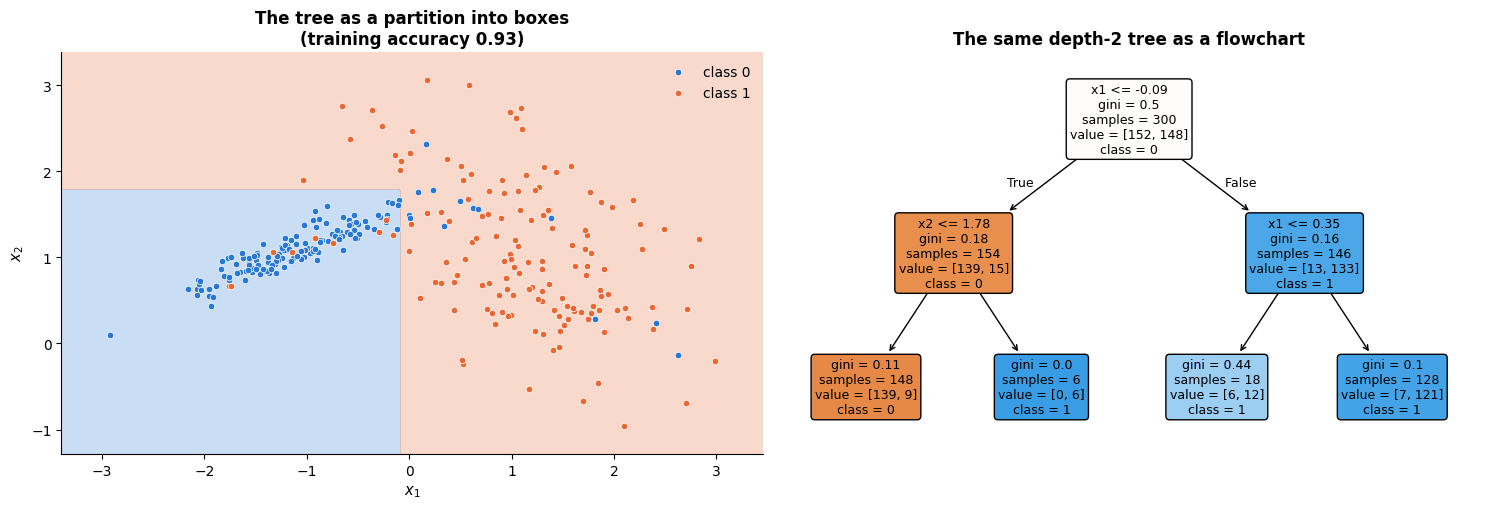

In [2]:
# make_classification generates a synthetic classification data set; DecisionTreeClassifier is scikit-learn's
# CART tree, and plot_tree draws a fitted tree as a flowchart
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 300 points with 2 features, both informative (n_redundant=0: no feature is a combination of the others);
# one blob per class, class_sep sets how far apart the classes sit, flip_y=0.08 re-draws 8 % of the labels at random
# e.g. x1, x2 = standardised income and debt of 300 loan applicants, class 1 = defaulted on the loan
X_toy, y_toy = make_classification(n_samples=300, n_features=2, n_redundant=0, n_informative=2,
                                   n_clusters_per_class=1, class_sep=1.1, flip_y=0.08,
                                   random_state=RANDOM_STATE)
# max_depth=2: at most two questions between the root and any leaf; .fit() returns the fitted model itself
toy_tree = DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE).fit(X_toy, y_toy)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
# left: the boxes the tree predicts; .score(X, y) is a classifier's accuracy on (X, y)
plot_decision_boundary(toy_tree, X_toy, y_toy, ax=axes[0], feature_names=("$x_1$", "$x_2$"),
                       title=f"The tree as a partition into boxes\n(training accuracy {toy_tree.score(X_toy, y_toy):.2f})")
# right: filled=True colours each node by its majority class, rounded=True rounds the boxes,
# precision=2 prints numbers with 2 decimals, impurity=True shows each node's Gini impurity
plot_tree(toy_tree, ax=axes[1], filled=True, rounded=True, fontsize=9, precision=2,
          feature_names=["x1", "x2"], class_names=["0", "1"], impurity=True)
axes[1].set_title("The same depth-2 tree as a flowchart")
plt.tight_layout()
plt.show()

Read the flowchart from the top: the root question, then one question in each branch, then
four leaves. Each leaf corresponds to exactly one rectangle in the left panel. `value` in
the node boxes is the class count, `gini` the impurity defined in the next section, and
`samples` the number of training points that reach the node.

> **History.** The idea of recursive partitioning goes back to AID (Morgan & Sonquist, 1963)
> in the social sciences. Two lines of work made it a machine-learning method: **CART**
> (Breiman, Friedman, Olshen & Stone, 1984), which introduced binary splits, Gini impurity,
> regression trees and cost-complexity pruning — this is what scikit-learn implements — and
> **ID3 / C4.5** (Quinlan, 1986, 1993), which used information gain, multi-way splits on
> categorical attributes, and a different pruning rule.

### 1.2 Prediction is a walk from the root to a leaf

Predicting is $O(\text{depth})$: compare one feature to one threshold, go left or right,
repeat. For a balanced tree with $L$ leaves the depth is $\log_2 L$, so prediction is
extremely fast and needs no arithmetic beyond comparisons — which is why trees are popular
in embedded and latency-critical systems.

> **Real-life example.** The Kinect motion sensor for the Xbox 360 labels every pixel of every
> depth image with a body part (head, hand, elbow, …) by sending it down a few deep decision
> trees, each question a cheap test on two depth readings near the pixel (Shotton et al., 2011).
> Because a prediction is only a short walk of such tests, millions of pixels per second can be
> labelled on a games console.

## 2. How a split is chosen

### 2.1 Measuring impurity

Let a node contain $n$ samples with class proportions $p_1, \dots, p_K$. We need a number
that is $0$ when the node is pure and largest when the classes are evenly mixed. The three
classical choices are

$$
\underbrace{H_G(p) = 1 - \sum_{k=1}^K p_k^2}_{\text{Gini impurity}},
\qquad
\underbrace{H_E(p) = -\sum_{k=1}^K p_k \log_2 p_k}_{\text{entropy}},
\qquad
\underbrace{H_M(p) = 1 - \max_k p_k}_{\text{misclassification rate}} .
$$

Each has an interpretation. **Gini** is the probability that two points drawn at random from
the node have different labels — equivalently, the error rate of a classifier that guesses a
label from the node's own distribution. **Entropy** is the expected number of bits needed to
encode the label (notebook 2), so the impurity *decrease* is the classical **information
gain**. The **misclassification rate** is the error of the majority-class rule.

> **Real-life example.** A node of an insurer's fraud tree holds 100 claims, 20 of them
> fraudulent. Its Gini impurity is 1 − 0.8² − 0.2² = 0.32: two claims drawn at random from the
> node have different labels 32 % of the time. Its entropy is 0.72 bits, and its
> misclassification rate is 0.2 — calling every claim in the node genuine gets 20 of them wrong.

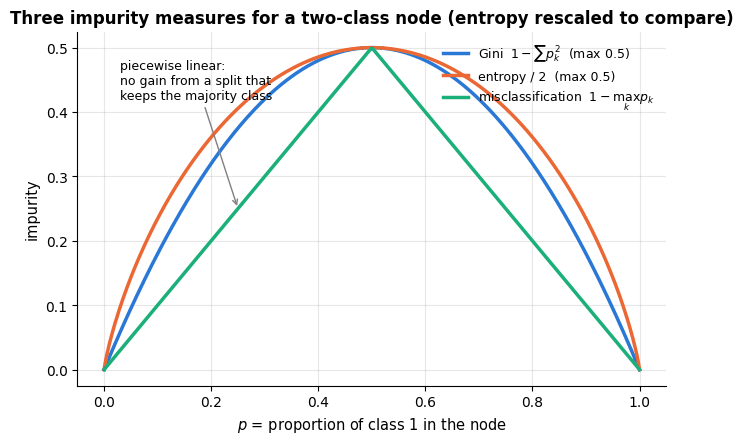

In [3]:
# 400 values of p, the proportion of class 1; the ends are nudged inwards because log2(0) is undefined
p = np.linspace(1e-6, 1 - 1e-6, 400)
gini_curve = 1 - (p ** 2 + (1 - p) ** 2)                       # two classes, with proportions p and 1 - p
entropy_curve = -(p * np.log2(p) + (1 - p) * np.log2(1 - p))   # in bits, so its maximum (at p = 0.5) is 1
misclass_curve = 1 - np.maximum(p, 1 - p)                      # np.maximum: the larger of the two, element by element

fig, ax = plt.subplots(figsize=(7.6, 4.6))
ax.plot(p, gini_curve, lw=2.5, color=PALETTE[0], label="Gini  $1-\\sum p_k^2$  (max 0.5)")
ax.plot(p, entropy_curve / 2, lw=2.5, color=PALETTE[1], label="entropy / 2  (max 0.5)")
ax.plot(p, misclass_curve, lw=2.5, color=PALETTE[2], label="misclassification  $1-\\max_k p_k$")
# a dotted triangle through (0, 0), (0.5, 0.5), (1, 0): the misclassification curve is exactly two straight lines
ax.plot([0, 0.5, 1], [0, 0.5, 0], color=PALETTE[2], ls=":", lw=1.2)
# annotate(text, xy=point, xytext=text position, arrowprops=...) writes the text with an arrow pointing at xy
ax.annotate("piecewise linear:\nno gain from a split that\nkeeps the majority class",
            xy=(0.25, 0.25), xytext=(0.03, 0.42), fontsize=9,
            arrowprops=dict(arrowstyle="->", color="gray"))
ax.set_xlabel("$p$ = proportion of class 1 in the node")
ax.set_ylabel("impurity")
ax.set_title("Three impurity measures for a two-class node (entropy rescaled to compare)")
ax.legend(loc="upper right", fontsize=9)
plt.show()

All three vanish at $p = 0$ and $p = 1$ and peak at $p = 0.5$. The crucial difference is
**curvature**: Gini and entropy are *strictly* concave, the misclassification rate is only
piecewise linear. We will see in section 2.3 why that matters.

### 2.2 The best split

Let a split $s$ send $n_L$ samples left and $n_R$ right. The **impurity decrease** (the
"gain") is the parent impurity minus the weighted average of the children's:

$$
\Delta(s) \;=\; H(\text{parent}) \;-\; \frac{n_L}{n}H(\text{left}) \;-\; \frac{n_R}{n}H(\text{right}).
$$

CART chooses, at every node, the $(j, t)$ that maximises $\Delta$. This is a **greedy**
choice: it never looks ahead to what the children could achieve later, and the globally
optimal tree of a given size is NP-hard to find (Hyafil & Rivest, 1976). Greediness is the
price of tractability, and it is one reason trees are unstable (section 8).

> **Real-life example.** Split the insurer's node of 100 claims (20 fraudulent) by "filed within
> a month of taking out the policy?". If 30 claims answer yes, 15 of them fraudulent, and 70
> answer no, 5 of them fraudulent, the children have Gini impurities 0.5 and 0.13, their
> weighted average is 0.3 × 0.5 + 0.7 × 0.13 ≈ 0.24, and the gain is 0.32 − 0.24 = 0.08. CART
> computes this for every feature and threshold and keeps the question with the largest gain.

For a numeric feature only the *order* of the values matters, so it is enough to try the
midpoints between consecutive distinct values. Sorting each feature once costs
$O(n \log n)$, and sweeping a threshold while updating the class counts incrementally costs
$O(n)$, giving $O(d\, n \log n)$ per node and roughly $O(d\, n \log^2 n)$ for a balanced
tree.

> **Key idea.** Because the split depends only on the *ranks* of a feature's values, a
> decision tree is invariant to any strictly increasing transformation of a feature — $x$,
> $\log x$, $x^3$ and $x/1000$ all give the identical tree. **Trees never need feature
> scaling.** This is a genuine, unusual convenience: kNN (notebook 8), SVMs (notebook 11)
> and penalised linear models (notebooks 6–7) all break without it.

### 2.3 One split, by hand

Let us implement the sweep and look at the gain as a function of the threshold for each
feature. The best point of this curve is the root of the tree that scikit-learn builds.

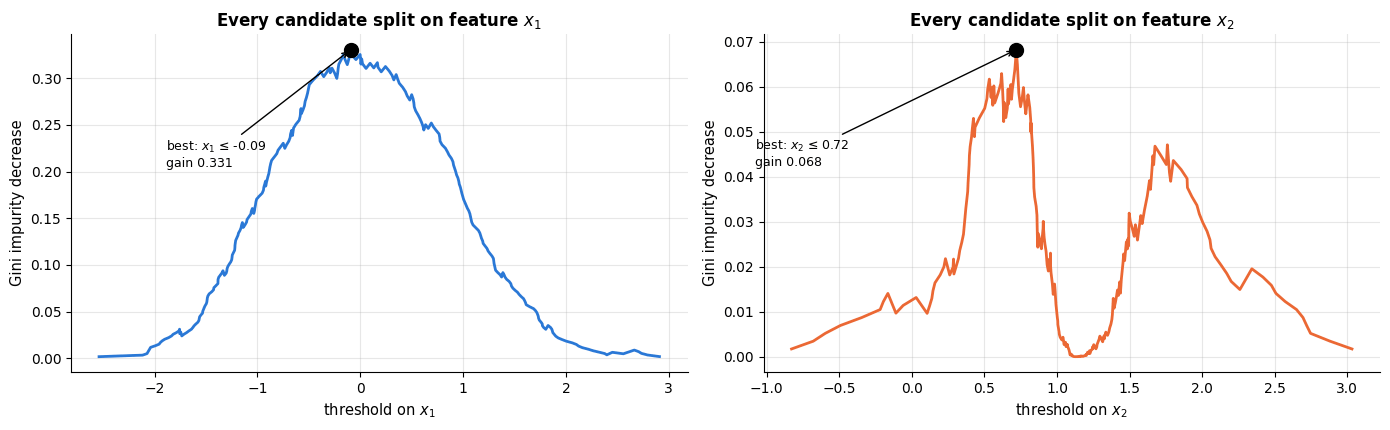

our best split:        feature 0, threshold -0.0935, gain 0.3307
scikit-learn's root:   feature 0, threshold -0.0935


In [4]:
def gini_impurity(counts):
    """Gini impurity 1 - sum_k p_k**2 of a node, given its per-class counts.

    counts is a 1-D array with one count per class. An empty node (all counts 0) returns 0.
    """
    total = counts.sum()
    if total == 0:
        return 0.0
    p = counts / total                          # class proportions p_k
    return float(1.0 - np.sum(p ** 2))          # float() turns the NumPy scalar into a plain Python float

def split_gains(x, y, n_classes):
    """Impurity decrease for every candidate threshold on one numeric feature.

    x          one feature's values, shape (n,)
    y          integer class labels 0 .. n_classes-1, shape (n,)
    n_classes  the number of classes K
    Returns (thresholds, gains): two 1-D arrays with one entry per midpoint between consecutive
    distinct values of x, where gains[i] is the Gini decrease of the split "x <= thresholds[i]".
    """
    # np.argsort gives the positions that would sort x; kind="mergesort" is a stable sort (ties keep their order)
    order = np.argsort(x, kind="mergesort")
    xs, ys = x[order], y[order]                 # feature values and labels, both sorted by the feature
    n = len(ys)
    # np.bincount counts how often each integer 0, 1, ... occurs; minlength guarantees one count per class
    parent = np.bincount(ys, minlength=n_classes)
    left, right = np.zeros(n_classes), parent.astype(float)     # start with every point in the right child
    thresholds, gains = [], []
    for i in range(n - 1):
        # move point i from the right child to the left one: the counts are updated, not recounted
        left[ys[i]] += 1
        right[ys[i]] -= 1
        if xs[i] == xs[i + 1]:                       # a threshold must separate distinct values
            continue
        n_l, n_r = i + 1, n - i - 1                  # sizes of the left child (points 0..i) and the right child
        # parent impurity minus the size-weighted impurities of the two children (the formula of section 2.2)
        gain = (gini_impurity(parent) - n_l / n * gini_impurity(left) - n_r / n * gini_impurity(right))
        thresholds.append(0.5 * (xs[i] + xs[i + 1]))     # the midpoint between the two neighbouring values
        gains.append(gain)
    return np.array(thresholds), np.array(gains)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
best_overall = (-np.inf, None, None)            # (gain, feature index, threshold) of the best split found so far
for j, ax in enumerate(axes):                   # j = 0, 1: one panel per feature
    thr, gains = split_gains(X_toy[:, j], y_toy, 2)      # X_toy[:, j] is column j, shape (300,); 2 classes
    ax.plot(thr, gains, lw=2, color=PALETTE[j])
    k = int(np.argmax(gains))                   # position of the largest gain
    ax.plot(thr[k], gains[k], "o", ms=10, color="black")     # "o": a circle marker and no line; ms = marker size
    ax.annotate(f"best: $x_{j+1}$ ≤ {thr[k]:.2f}\ngain {gains[k]:.3f}", xy=(thr[k], gains[k]),
                xytext=(thr[k] - 1.8, gains[k] * 0.62), fontsize=9,
                arrowprops=dict(arrowstyle="->", color="black"))
    ax.set_xlabel(f"threshold on $x_{j+1}$")
    ax.set_ylabel("Gini impurity decrease")
    ax.set_title(f"Every candidate split on feature $x_{j+1}$")
    if gains[k] > best_overall[0]:              # keep whichever feature offers the larger best gain
        best_overall = (gains[k], j, thr[k])
plt.tight_layout()
plt.show()

print(f"our best split:        feature {best_overall[1]}, threshold {best_overall[2]:.4f}, gain {best_overall[0]:.4f}")
# a fitted tree's raw structure lives in .tree_: .feature[node] and .threshold[node] describe each node's split,
# and node 0 is the root
print(f"scikit-learn's root:   feature {toy_tree.tree_.feature[0]}, threshold {toy_tree.tree_.threshold[0]:.4f}")

The two curves are exactly what CART maximises; the higher of the two peaks is the root
split, and it agrees with scikit-learn to four decimal places.

> **Going deeper — why not the misclassification rate?** Consider a node with 400 samples,
> 200 of each class, and a split producing (300: 200/100) and (100: 0/100). The
> misclassification rate is $0.5$ before and $\frac{300}{400}\cdot\frac13 + \frac{100}{400}\cdot 0 = 0.25$
> after — but so is it for the split (200: 150/50), (200: 50/150). The linear measure cannot
> distinguish them, while Gini clearly prefers the first (gain $0.167$ versus $0.125$)
> because it produces a *pure* node. Worse, the misclassification rate assigns *zero* gain to
> any split that leaves the majority class
> unchanged in both children, so the greedy search stalls. Strict concavity guarantees
> $\Delta(s) \ge 0$ with equality only for a useless split, which is why Gini and entropy are
> used for *growing* while the misclassification rate is used for *pruning* (Hastie et al.,
> 2009, §9.2.3).

## 3. CART from scratch

Everything needed is now in place: the impurity, the sweep, and a stopping rule. The
recursive builder is thirty lines.

In [5]:
def best_split(X, y, n_classes, min_samples_leaf):
    """Return (gain, feature, threshold) of the best split, or (0, None, None) if none is useful.

    Tries every feature j of X (shape (n, d)) with split_gains and keeps the largest gain among
    the thresholds that leave at least min_samples_leaf points on each side.
    """
    best = (0.0, None, None)                     # only a split with a positive gain can replace this
    for j in range(X.shape[1]):                  # X.shape[1] = number of features d
        thr, gains = split_gains(X[:, j], y, n_classes)
        if len(gains) == 0:                      # the feature is constant in this node: no threshold exists
            continue
        # respect min_samples_leaf: a threshold is legal only if both sides are big enough
        # np.searchsorted(sorted_values, thr, side="right") counts, for each threshold, the values <= it (the left size)
        counts_left = np.searchsorted(np.sort(X[:, j]), thr, side="right")
        legal = (counts_left >= min_samples_leaf) & (len(y) - counts_left >= min_samples_leaf)
        if not legal.any():                      # .any(): is at least one entry True?
            continue
        k = int(np.argmax(np.where(legal, gains, -np.inf)))     # best legal threshold (illegal ones get -inf)
        if gains[k] > best[0] + 1e-12:           # strictly better (up to round-off), so on a tie the earlier feature wins
            best = (float(gains[k]), j, float(thr[k]))
    return best

def grow_tree(X, y, n_classes, depth, max_depth, min_samples_split, min_samples_leaf):
    """Recursively grow a CART classification tree; a node is a dict.

    Every node stores "proba" (its class proportions), "n" (its number of samples) and "feature"
    (None for a leaf). A split node also stores "threshold", "gain" and two child nodes:
    "left" for the samples with x[feature] <= threshold, "right" for the rest.
    depth is this node's depth (0 at the root); max_depth, min_samples_split and min_samples_leaf
    are the stopping rules. Returns the node grown from (X, y).
    """
    # class proportions in this node: the predicted probabilities if the node ends up a leaf
    node = {"proba": np.bincount(y, minlength=n_classes) / len(y), "n": len(y), "feature": None}
    # stop if the node is too deep, too small to split, or already pure (only one class left)
    if (depth >= max_depth or len(y) < min_samples_split or len(np.unique(y)) == 1):
        return node
    gain, j, t = best_split(X, y, n_classes, min_samples_leaf)
    if j is None:                                # no useful split: the node stays a leaf
        return node
    mask = X[:, j] <= t                          # True for the samples that go left
    # dict.update adds the split and both children, each grown recursively one level deeper;
    # ~mask (element-wise NOT) selects the samples that go right
    node.update(feature=j, threshold=t, gain=gain,
                left=grow_tree(X[mask], y[mask], n_classes, depth + 1, max_depth, min_samples_split, min_samples_leaf),
                right=grow_tree(X[~mask], y[~mask], n_classes, depth + 1, max_depth, min_samples_split, min_samples_leaf))
    return node

class MyDecisionTree:
    """A minimal CART classifier for numeric features, mirroring scikit-learn's API.

    The hyper-parameters have the same names as in DecisionTreeClassifier. After fit(),
    classes_ holds the sorted class labels and root_ the root node (a nested dict, see grow_tree).
    """

    def __init__(self, max_depth=3, min_samples_split=2, min_samples_leaf=1):
        """Store the stopping rules; nothing is learned until fit() is called."""
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf

    def fit(self, X, y):
        """Grow the tree on X (shape (n_samples, n_features)) and labels y; returns self, so calls can be chained."""
        self.classes_ = np.unique(y)                       # the sorted distinct labels
        y_idx = np.searchsorted(self.classes_, y)          # each label -> its position in classes_ (0 .. K-1)
        # np.asarray(X, dtype=float) turns lists or DataFrames into a float array; the root starts at depth 0
        self.root_ = grow_tree(np.asarray(X, dtype=float), y_idx, len(self.classes_), 0,
                               self.max_depth, self.min_samples_split, self.min_samples_leaf)
        return self

    def predict_proba(self, X):
        """Class probabilities of shape (n_samples, n_classes): the class proportions of the leaf each row reaches."""
        X = np.asarray(X, dtype=float)
        out = np.empty((len(X), len(self.classes_)))
        for i, x in enumerate(X):                          # one row (sample) at a time
            node = self.root_
            while node["feature"] is not None:             # walk down until a leaf is reached
                node = node["left"] if x[node["feature"]] <= node["threshold"] else node["right"]
            out[i] = node["proba"]
        return out

    def predict(self, X):
        """Predicted labels: the most probable class in each row's leaf."""
        # argmax(axis=1) is the column of the largest probability in each row; classes_[...] maps it back to a label
        return self.classes_[self.predict_proba(X).argmax(axis=1)]

Now the verification that matters: does it reproduce scikit-learn *exactly*?

In [6]:
from sklearn.datasets import load_wine

# load_wine() returns a Bunch (a dict whose keys are also attributes): .data is (178, 13), .target holds the
# cultivar 0, 1 or 2, plus .feature_names and .target_names
wine = load_wine()
rows = []                                   # one dict per (depth, data set) combination -> one table row each
for depth in [1, 2, 3, 5]:
    # each list entry is (name, (X, y)); the nested tuple is unpacked straight into name, Xd and yd
    for name, (Xd, yd) in [("2-D toy", (X_toy, y_toy)), ("wine (13 features)", (wine.data, wine.target))]:
        ours = MyDecisionTree(max_depth=depth).fit(Xd, yd)
        theirs = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE).fit(Xd, yd)
        rows.append({"data": name, "max_depth": depth,
                     "our accuracy": (ours.predict(Xd) == yd).mean(),      # the mean of True/False = fraction correct
                     "sklearn accuracy": theirs.score(Xd, yd),
                     "predictions agree": (ours.predict(Xd) == theirs.predict(Xd)).mean()})
pd.DataFrame(rows)                          # a list of dicts becomes a table: one row per dict, keys -> columns

,data,max_depth,our accuracy,sklearn accuracy,predictions agree
0,2-D toy,1,0.906667,0.906667,1.0
1,wine (13 features),1,0.696629,0.696629,1.0
2,2-D toy,2,0.926667,0.926667,1.0
3,wine (13 features),2,0.921348,0.921348,1.0
4,2-D toy,3,0.926667,0.926667,1.0
5,wine (13 features),3,0.977528,0.977528,1.0
6,2-D toy,5,0.956667,0.956667,1.0
7,wine (13 features),5,1.000000,1.000000,1.0


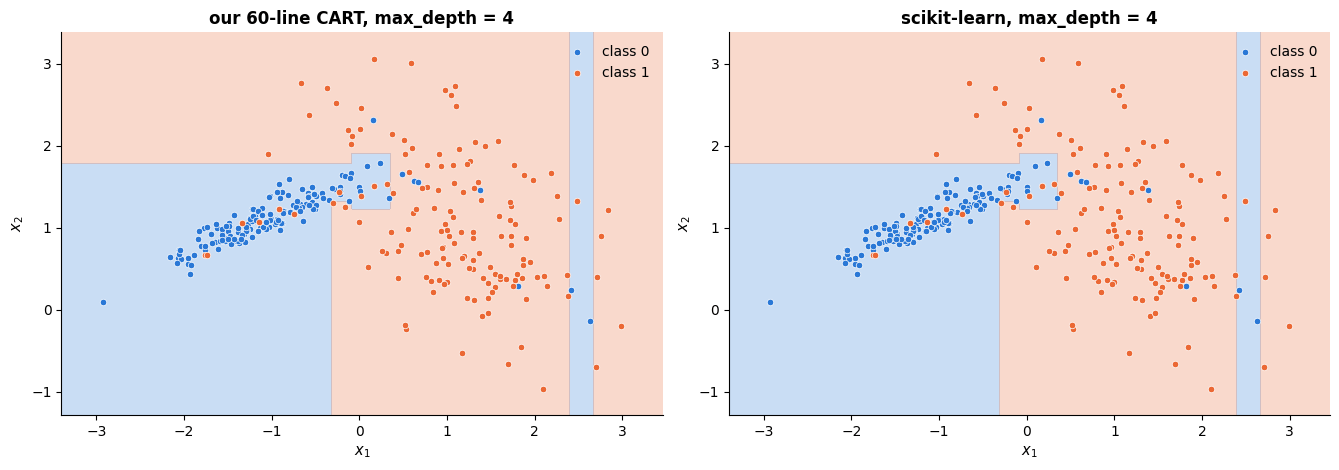

the two models agree on 100.000% of a 200 × 200 grid covering the whole plane


In [7]:
ours_4 = MyDecisionTree(max_depth=4).fit(X_toy, y_toy)
theirs_4 = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE).fit(X_toy, y_toy)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
# plot_decision_boundary works with our class too, because it only calls the model's .predict()
plot_decision_boundary(ours_4, X_toy, y_toy, ax=axes[0], feature_names=("$x_1$", "$x_2$"),
                       title="our 60-line CART, max_depth = 4")
plot_decision_boundary(theirs_4, X_toy, y_toy, ax=axes[1], feature_names=("$x_1$", "$x_2$"),
                       title="scikit-learn, max_depth = 4")
plt.tight_layout()
plt.show()

# np.meshgrid gives two 200 x 200 arrays holding the x- and y-coordinates of a grid over the plane;
# np.c_[a, b] puts the flattened coordinates side by side as columns -> grid_pts has shape (40000, 2)
gx, gy = np.meshgrid(np.linspace(-3.5, 3.5, 200), np.linspace(-1.5, 3.5, 200))
grid_pts = np.c_[gx.ravel(), gy.ravel()]
# :.3% formats a fraction as a percentage with 3 decimals
print(f"the two models agree on {(ours_4.predict(grid_pts) == theirs_4.predict(grid_pts)).mean():.3%} "
      f"of a 200 × 200 grid covering the whole plane")

Identical accuracies, 100 % agreement on every training prediction, and identical decision
regions on a grid covering the whole plane — not merely a similar model, the *same* model.
scikit-learn's implementation is this algorithm written in Cython, with sparse-matrix
support, sample weights, several criteria, class weights and pruning added.

> **Warning.** Ties are resolved arbitrarily. When two splits have the same gain, our
> implementation takes the first and scikit-learn takes whichever its (randomised) feature
> order reaches first — which is why `DecisionTreeClassifier` has a `random_state` at all
> even though the algorithm is deterministic. On data with many duplicated values the two
> implementations can legitimately produce different (equally good) trees.

## 4. Reading a fitted tree

A tree is worth fitting partly for the picture. Two views: `plot_tree` for the structure and
`export_text` for a rule list you can paste into an email.

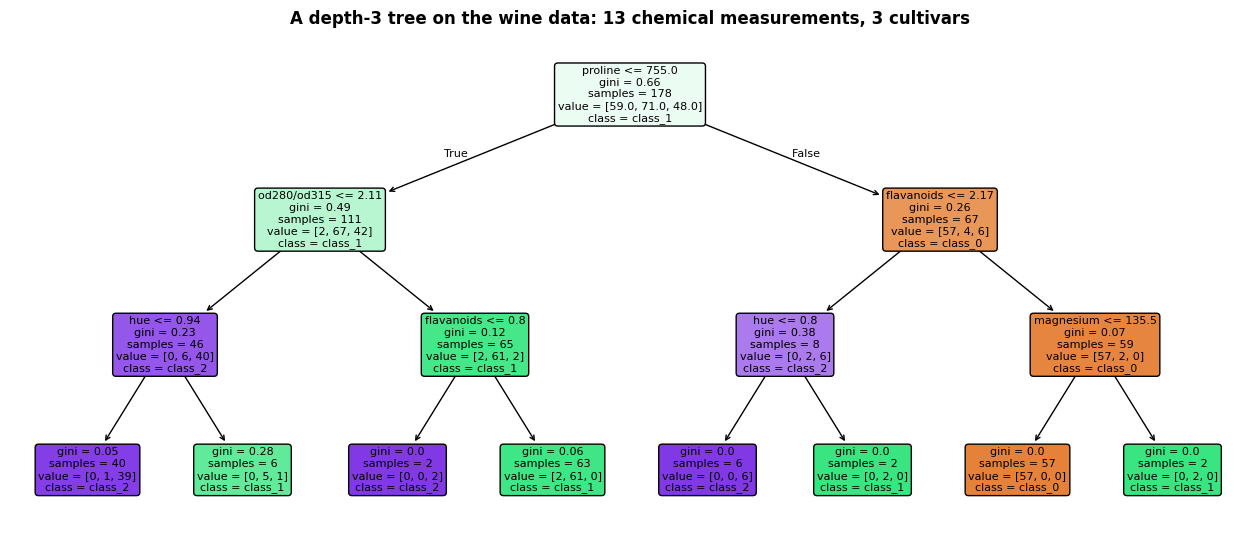

|--- proline <= 755.00
|   |--- od280/od315_of_diluted_wines <= 2.11
|   |   |--- hue <= 0.94
|   |   |   |--- class: 2
|   |   |--- hue >  0.94
|   |   |   |--- class: 1
|   |--- od280/od315_of_diluted_wines >  2.11
|   |   |--- flavanoids <= 0.80
|   |   |   |--- class: 2
|   |   |--- flavanoids >  0.80
|   |   |   |--- class: 1
|--- proline >  755.00
|   |--- flavanoids <= 2.17
|   |   |--- hue <= 0.80
|   |   |   |--- class: 2
|   |   |--- hue >  0.80
|   |   |   |--- class: 1
|   |--- flavanoids >  2.17
|   |   |--- magnesium <= 135.50
|   |   |   |--- class: 0
|   |   |--- magnesium >  135.50
|   |   |   |--- class: 1



In [8]:
from sklearn.tree import export_text          # export_text writes a fitted tree as indented if/else rules

wine_tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE).fit(wine.data, wine.target)
# plot_tree does not wrap long names, so shorten them for the drawing only
# (abbreviate the one very long name, then [:16] keeps at most the first 16 characters of every name)
short_names = [name.replace("od280/od315_of_diluted_wines", "od280/od315")[:16] for name in wine.feature_names]
fig, ax = plt.subplots(figsize=(16, 6.5))
# proportion=False shows raw counts in "samples" and "value" (True would show fractions instead)
plot_tree(wine_tree, ax=ax, filled=True, rounded=True, fontsize=8, precision=2, proportion=False,
          feature_names=short_names, class_names=list(wine.target_names))
ax.set_title("A depth-3 tree on the wine data: 13 chemical measurements, 3 cultivars")
plt.show()
print(export_text(wine_tree, feature_names=list(wine.feature_names), decimals=2))   # thresholds with 2 decimals

Colour encodes the majority class, saturation its purity. Note how few of the 13 features
the tree uses: a greedy tree of depth 3 asks at most 7 questions in total, which is precisely
why it is readable — and why it may ignore informative features that are correlated with the
ones it happened to pick first.

### 4.1 Depth is capacity

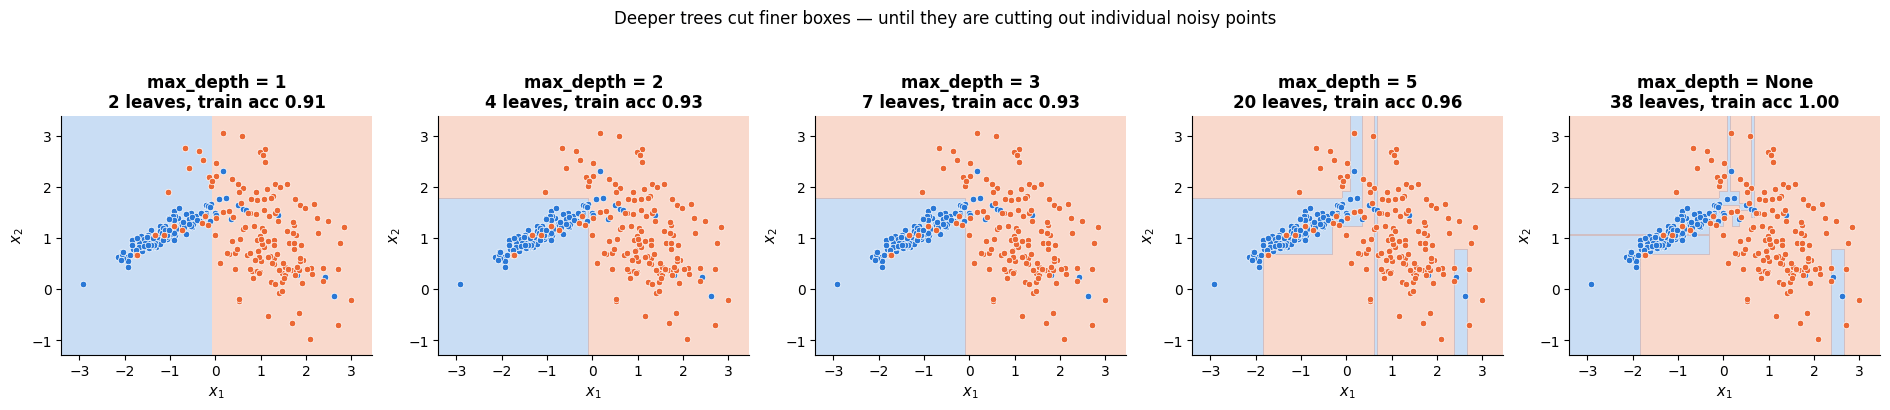

In [9]:
depths = [1, 2, 3, 5, None]                          # None = no depth limit: grow until every leaf is pure
fig, axes = plt.subplots(1, len(depths), figsize=(19, 3.9))
for ax, depth in zip(axes, depths):                  # zip pairs each panel with one depth
    model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE).fit(X_toy, y_toy)
    # get_n_leaves() is the number of leaves of the fitted tree; two f-strings side by side join into one string
    plot_decision_boundary(model, X_toy, y_toy, ax=ax, feature_names=("$x_1$", "$x_2$"),
                           title=f"max_depth = {depth}\n{model.get_n_leaves()} leaves, "
                                 f"train acc {model.score(X_toy, y_toy):.2f}")
    ax.legend().remove()                             # drop the legend that plot_decision_boundary added to each panel
fig.suptitle("Deeper trees cut finer boxes — until they are cutting out individual noisy points", y=1.04)
plt.tight_layout()
plt.show()

At `max_depth=None` the tree grows until every leaf is pure: training accuracy 1.0, and a
scattering of thin slivers carved around single mislabelled points. That is overfitting in
its purest visual form, and section 6 is about preventing it.

> **Real-life example.** A fully grown tree on an online shop's orders, predicting which will be
> returned, ends up with leaves such as "size 38 boots, ordered after 23:00 on a Sunday, paid by
> voucher → returned" that hold a single order, perhaps one returned by mistake. Such a leaf
> describes one customer's evening, not a pattern the next customer will follow.

## 5. Regression trees

### 5.1 The variance criterion

Nothing structural changes for a numeric target: only the impurity and the leaf value do.
With squared-error loss the best constant prediction in a node is the mean of its targets,
and the impurity is the node's variance,

$$
H(\text{node}) \;=\; \frac{1}{n}\sum_{i \in \text{node}} \big(y_i - \bar{y}_{\text{node}}\big)^2 ,
$$

so maximising the impurity decrease is exactly minimising the total within-node sum of
squares. `criterion="squared_error"` is the default; `"absolute_error"` uses the median in
each leaf and is robust to outliers but much slower; `"friedman_mse"` is a variant used
inside gradient boosting (notebook 10).

> **Real-life example.** An estate agent's regression tree for flat prices might first ask "floor
> area at most 60 m²?", because that question makes the prices on each side as uniform as
> possible (the smallest within-node sum of squares); each leaf then predicts the average price
> of its flats. With `"absolute_error"` a leaf predicts the median instead, so one penthouse sold
> for ten times the usual price cannot drag its leaf's prediction upwards.

### 5.2 The fitted function is a staircase

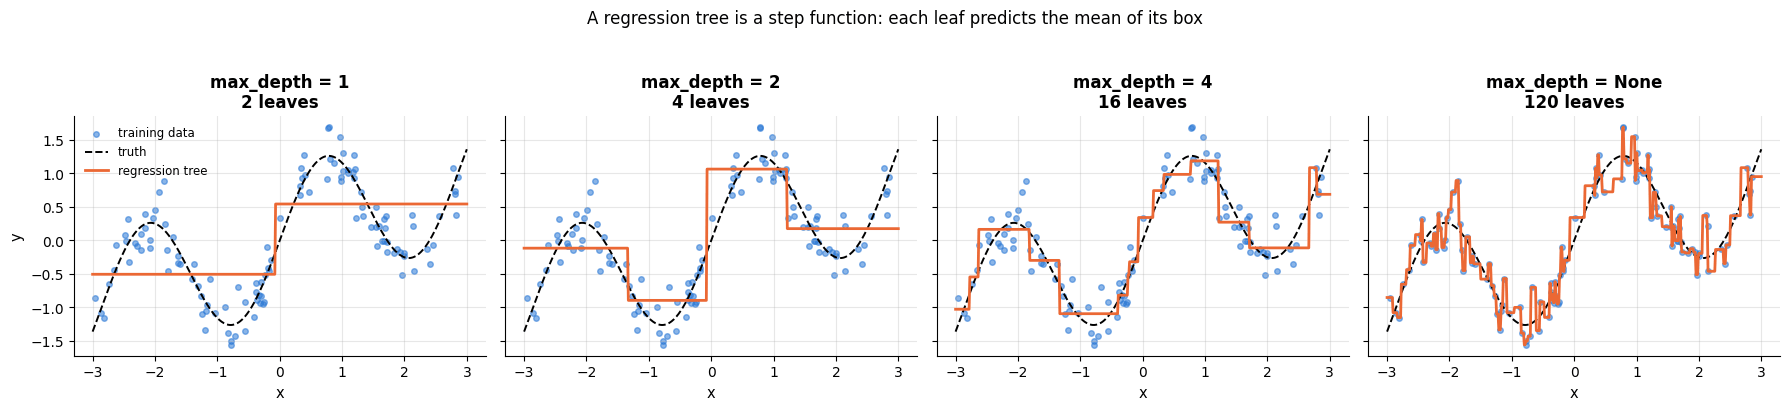

In [10]:
from sklearn.tree import DecisionTreeRegressor      # the regression version: each leaf predicts the mean target

def true_curve(x):
    """The noise-free target sin(2.2 x) + 0.35 x that the regression trees try to recover (works element-wise)."""
    return np.sin(2.2 * x) + 0.35 * x

# e.g. x = time over about two years (rescaled), y = weekly sales of a seasonal product: a yearly cycle plus growth
x_reg = np.sort(rng.uniform(-3, 3, 120))                       # 120 sorted x-values, uniform on [-3, 3)
y_reg = true_curve(x_reg) + rng.normal(0, 0.25, len(x_reg))    # the curve plus Gaussian noise with sd 0.25
grid_reg = np.linspace(-3, 3, 500)[:, None]                    # shape (500, 1): scikit-learn wants a 2-D X

fig, axes = plt.subplots(1, 4, figsize=(18, 3.9), sharey=True)    # sharey: all four panels use the same y-axis
for ax, depth in zip(axes, [1, 2, 4, None]):
    # x_reg[:, None] turns the (120,) vector into a (120, 1) matrix with a single feature
    reg = DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_STATE).fit(x_reg[:, None], y_reg)
    ax.scatter(x_reg, y_reg, s=16, alpha=0.55, color=PALETTE[0], label="training data")   # s = marker size
    ax.plot(grid_reg, true_curve(grid_reg), color="black", lw=1.4, ls="--", label="truth")
    ax.plot(grid_reg, reg.predict(grid_reg), color=PALETTE[1], lw=2, label="regression tree")
    ax.set_title(f"max_depth = {depth}\n{reg.get_n_leaves()} leaves")
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend(fontsize=8.5, loc="upper left")
fig.suptitle("A regression tree is a step function: each leaf predicts the mean of its box", y=1.04)
plt.tight_layout()
plt.show()

Each additional level doubles the number of steps available. With unlimited depth the
staircase passes through every training point — zero training error, and a function that
mostly describes the noise.

### 5.3 Trees cannot extrapolate

The prediction of a leaf is the mean of the training targets that fell in it. Outside the
range of the training data there is no new box: the outermost leaves extend to infinity, so
the prediction is **flat forever**. For a trend that continues — prices, growth, time
(notebook 16) — this is a fatal flaw that a linear model does not have.

> **Real-life example.** A grid operator's tree predicts electricity demand from temperature,
> trained on days between −10 and 32 °C. On a 38 °C heatwave day it predicts exactly the demand
> of its hottest leaf, although every extra degree switches on more air-conditioning; a model
> with a linear temperature term would at least keep rising.

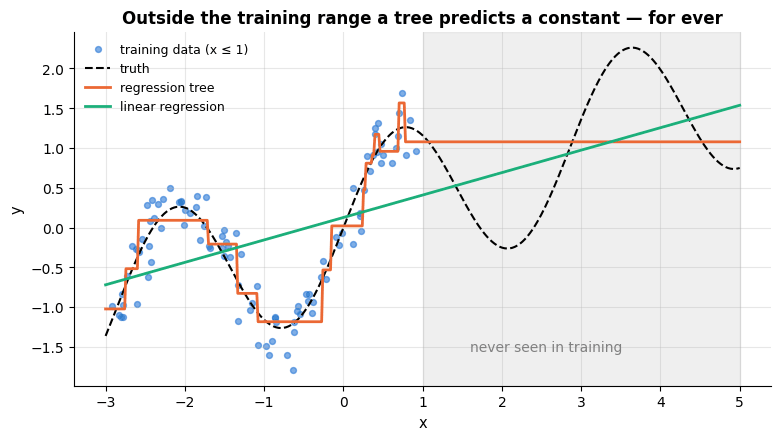

In [11]:
from sklearn.linear_model import LinearRegression

# e.g. the sales history only reaches x = 1; everything to the right of it is the future to be forecast
x_train_ex = np.sort(rng.uniform(-3, 1, 100))          # the training inputs only cover [-3, 1)
y_train_ex = true_curve(x_train_ex) + rng.normal(0, 0.25, len(x_train_ex))
grid_ex = np.linspace(-3, 5, 500)[:, None]             # predict out to x = 5, well beyond the training range

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.axvspan(1, 5, color="gray", alpha=0.12)             # axvspan shades the vertical band 1 <= x <= 5
ax.text(1.6, -1.55, "never seen in training", color="gray", fontsize=10)
ax.scatter(x_train_ex, y_train_ex, s=18, alpha=0.6, color=PALETTE[0], label="training data (x ≤ 1)")
ax.plot(grid_ex, true_curve(grid_ex), color="black", lw=1.5, ls="--", label="truth")
# fit and predict in one expression: .fit() returns the model, so .predict() can be chained onto it
ax.plot(grid_ex, DecisionTreeRegressor(max_depth=4, random_state=RANDOM_STATE)
        .fit(x_train_ex[:, None], y_train_ex).predict(grid_ex), color=PALETTE[1], lw=2, label="regression tree")
ax.plot(grid_ex, LinearRegression().fit(x_train_ex[:, None], y_train_ex).predict(grid_ex),
        color=PALETTE[2], lw=2, label="linear regression")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Outside the training range a tree predicts a constant — for ever")
ax.legend(fontsize=9, loc="upper left")
plt.show()

The linear model is wrong in a different way (it never had the right shape), but its error
grows slowly; the tree's prediction simply stops responding to $x$. Ensembles of trees
inherit this limitation — a random forest cannot extrapolate either.

## 6. Overfitting, and how to prune

### 6.1 The overfitting curve

A fully grown tree memorises the training set. The cure is either to stop early
(*pre-pruning*: `max_depth`, `min_samples_leaf`, `min_samples_split`, `max_leaf_nodes`,
`min_impurity_decrease`) or to grow a large tree and cut it back (*post-pruning*:
`ccp_alpha`). Let us see the damage first, on a deliberately noisy problem.

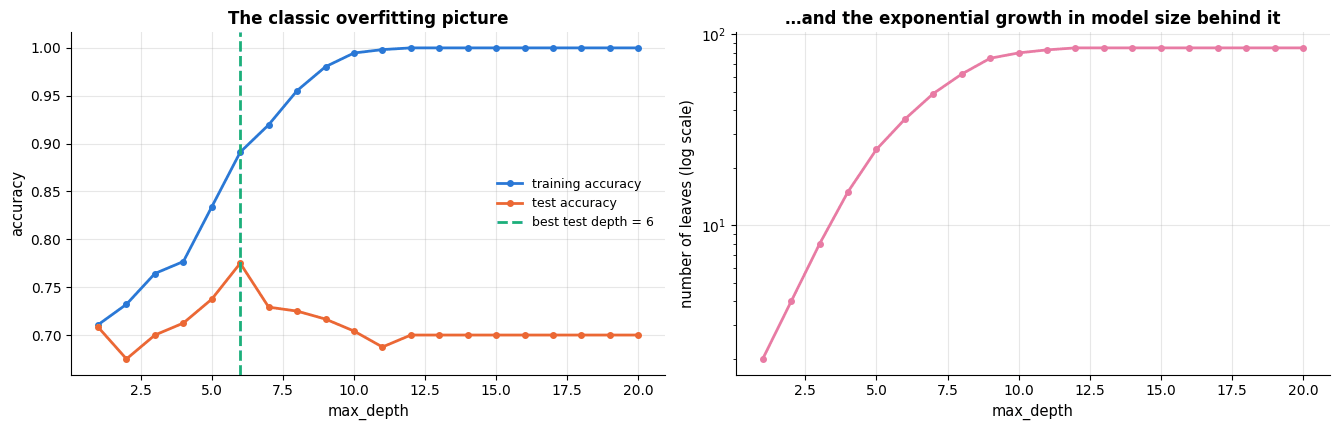

fully grown tree: 85 leaves, train accuracy 1.000, test accuracy 0.700


In [12]:
# StratifiedKFold makes k-fold CV splits that keep the class proportions in every fold; cross_val_score fits
# and scores a model once per fold; train_test_split makes a single random train/test split
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

# 800 points, 10 features: 4 informative, 2 redundant (combinations of the informative ones), the other 4 pure
# noise; class_sep=0.8 brings the classes closer and flip_y=0.12 adds label noise, so deep trees overfit
# e.g. 10 lab measurements per patient, 4 of them relevant, and diagnoses with recording errors (flip_y)
X_noisy, y_noisy = make_classification(n_samples=800, n_features=10, n_informative=4, n_redundant=2,
                                       class_sep=0.8, flip_y=0.12, random_state=RANDOM_STATE)
# hold out 30 % as a test set; stratify=y_noisy keeps the class balance the same in both parts
Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(X_noisy, y_noisy, test_size=0.3, stratify=y_noisy,
                                              random_state=RANDOM_STATE)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)    # 5 folds, rows shuffled first

depth_grid = np.arange(1, 21)                    # depths 1, 2, ..., 20
train_acc, test_acc, n_leaves = [], [], []
for depth in depth_grid:
    # int(depth) turns the NumPy integer into a plain Python int
    model = DecisionTreeClassifier(max_depth=int(depth), random_state=RANDOM_STATE).fit(Xn_tr, yn_tr)
    train_acc.append(model.score(Xn_tr, yn_tr))
    test_acc.append(model.score(Xn_te, yn_te))
    n_leaves.append(model.get_n_leaves())

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
axes[0].plot(depth_grid, train_acc, "-o", ms=4, color=PALETTE[0], label="training accuracy")   # "-o": line and dots
axes[0].plot(depth_grid, test_acc, "-o", ms=4, color=PALETTE[1], label="test accuracy")
best_depth = int(depth_grid[int(np.argmax(test_acc))])           # the depth with the highest test accuracy
axes[0].axvline(best_depth, color=PALETTE[2], ls="--", label=f"best test depth = {best_depth}")
axes[0].set_xlabel("max_depth")
axes[0].set_ylabel("accuracy")
axes[0].set_title("The classic overfitting picture")
axes[0].legend(fontsize=9)
axes[1].plot(depth_grid, n_leaves, "-o", ms=4, color=PALETTE[4])
axes[1].set_yscale("log")
axes[1].set_xlabel("max_depth")
axes[1].set_ylabel("number of leaves (log scale)")
axes[1].set_title("…and the exponential growth in model size behind it")
plt.tight_layout()
plt.show()
# [-1] is the last entry, depth 20: deep enough here for the tree to be fully grown
print(f"fully grown tree: {n_leaves[-1]} leaves, train accuracy {train_acc[-1]:.3f}, "
      f"test accuracy {test_acc[-1]:.3f}")

### 6.2 Cost-complexity (weakest-link) pruning

Pre-pruning has a known weakness: it is *myopic*. A split that looks useless may enable an
excellent split below it, and a depth limit that is right in one branch is wrong in another.
CART's answer is to grow the tree fully and then prune it back, penalising size. For a tree
$T$ with $|\tilde{T}|$ leaves define the **cost-complexity**

$$
R_\alpha(T) \;=\; R(T) \;+\; \alpha\,|\tilde{T}|,
$$

where $R(T)$ is the total (weighted) impurity of the leaves and $\alpha \ge 0$ is the price
of a leaf. Breiman et al. (1984) proved a remarkable fact: as $\alpha$ increases from $0$,
the minimisers of $R_\alpha$ form a *finite, nested* sequence of subtrees
$T_0 \supset T_1 \supset \dots \supset \{\text{root}\}$, each obtained from the previous one
by collapsing the "weakest link" — the internal node with the smallest increase in $R$ per
leaf removed. So we do not search over subtrees: we compute the whole sequence at once.
`cost_complexity_pruning_path` returns the $\alpha$ at which each collapse happens.

> **Real-life example.** A bank hands its credit tree to loan officers as a printed rule list and
> decides that every extra rule must cut the training impurity by at least a fixed amount to be
> worth a line in the manual. That fixed amount is α, the price of a leaf: grow the full tree,
> then collapse, weakest first, every branch whose improvement per leaf falls short of it.

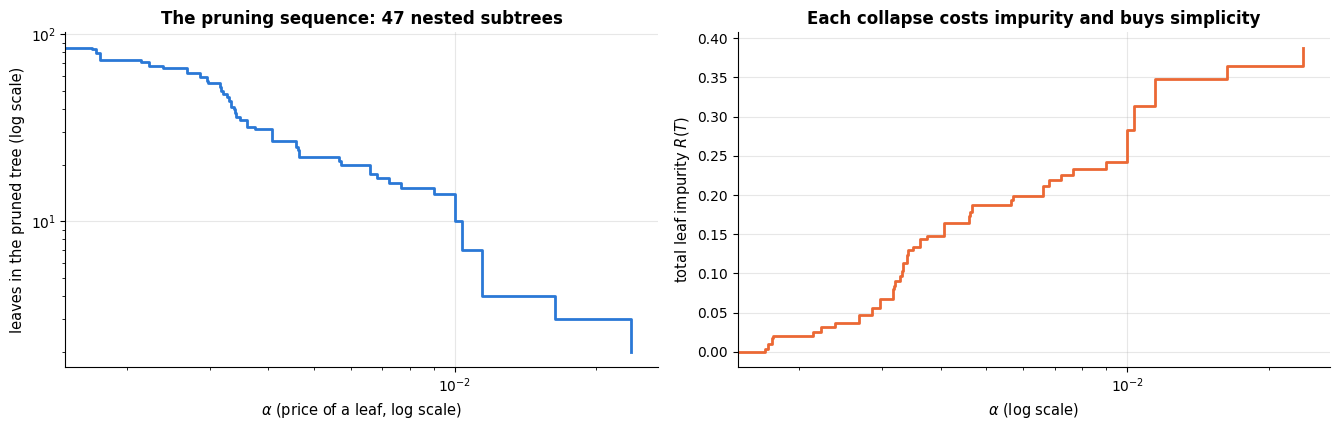

alpha ranges from 0.00e+00 to 0.024; leaves from 85 down to 2


In [13]:
full_tree = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(Xn_tr, yn_tr)     # no limits: fully grown
# cost_complexity_pruning_path returns .ccp_alphas, the increasing alphas at which each weakest-link collapse
# happens, and .impurities, the total leaf impurity R(T) of the subtree that belongs to each alpha
path = full_tree.cost_complexity_pruning_path(Xn_tr, yn_tr)
alphas, impurities = path.ccp_alphas[:-1], path.impurities[:-1]      # drop the root-only tree
# one refit per alpha: ccp_alpha=a grows the full tree, then prunes it back to the subtree of the sequence for a
pruned = [DecisionTreeClassifier(ccp_alpha=a, random_state=RANDOM_STATE).fit(Xn_tr, yn_tr) for a in alphas]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
# drawstyle="steps-post" draws a staircase: each value is held constant until the next alpha
axes[0].plot(alphas, [t.get_n_leaves() for t in pruned], drawstyle="steps-post", lw=2, color=PALETTE[0])
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel(r"$\alpha$ (price of a leaf, log scale)")
axes[0].set_ylabel("leaves in the pruned tree (log scale)")
axes[0].set_title(f"The pruning sequence: {len(alphas)} nested subtrees")
axes[1].plot(alphas, impurities, drawstyle="steps-post", lw=2, color=PALETTE[1])
axes[1].set_xscale("log")
axes[1].set_xlabel(r"$\alpha$ (log scale)")
axes[1].set_ylabel("total leaf impurity $R(T)$")
axes[1].set_title("Each collapse costs impurity and buys simplicity")
plt.tight_layout()
plt.show()
# :.2e prints in scientific notation with 2 decimals
print(f"alpha ranges from {alphas.min():.2e} to {alphas.max():.3f}; "
      f"leaves from {pruned[0].get_n_leaves()} down to {pruned[-1].get_n_leaves()}")

### 6.3 Choosing $\alpha$ by cross-validation

The sequence is free; picking a member of it is a model-selection problem like any other.

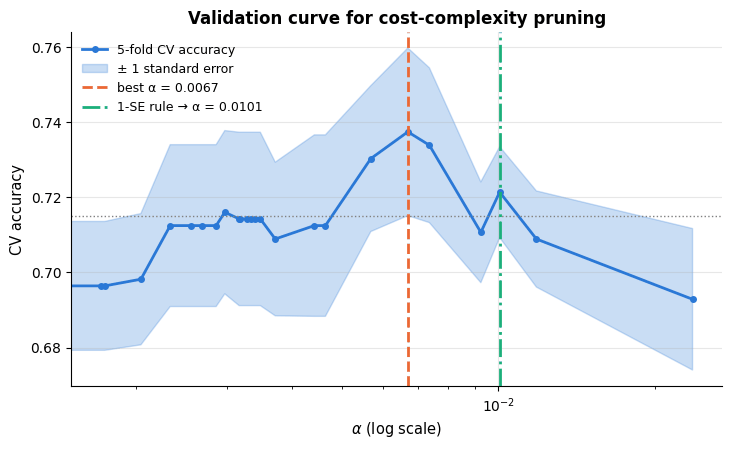

unpruned  α=0.0000    85 leaves  train 1.000  test 0.700
best α    α=0.0067    18 leaves  train 0.870  test 0.779
1-SE α    α=0.0101    10 leaves  train 0.812  test 0.758


In [14]:
# 25 evenly spaced quantiles (0 %, 4 %, ..., 100 %) of the path's alphas; np.unique sorts them and drops duplicates
alpha_grid = np.unique(np.quantile(alphas, np.linspace(0, 1, 25)))
cv_mean, cv_se = [], []
for a in alpha_grid:
    # cross_val_score(model, X, y, cv=cv5) returns one score per fold (accuracy, for a classifier)
    s = cross_val_score(DecisionTreeClassifier(ccp_alpha=a, random_state=RANDOM_STATE), Xn_tr, yn_tr, cv=cv5)
    cv_mean.append(s.mean())
    cv_se.append(s.std(ddof=1) / np.sqrt(len(s)))     # standard error of the mean: sample sd (ddof=1) / sqrt(5)
cv_mean, cv_se = np.array(cv_mean), np.array(cv_se)
best_i = int(np.argmax(cv_mean))
one_se_floor = cv_mean[best_i] - cv_se[best_i]        # one-SE rule: any alpha scoring at least this counts as "as good"
# np.flatnonzero(mask) lists the positions where mask is True; [-1] takes the last one, because alpha_grid is sorted
alpha_1se = float(alpha_grid[np.flatnonzero(cv_mean >= one_se_floor)[-1]])   # largest alpha = simplest tree

fig, ax = plt.subplots(figsize=(8.4, 4.6))
ax.plot(alpha_grid, cv_mean, "-o", ms=4, color=PALETTE[0], label="5-fold CV accuracy")
# fill_between(x, lower, upper) shades the band between two curves
ax.fill_between(alpha_grid, cv_mean - cv_se, cv_mean + cv_se, alpha=0.25, color=PALETTE[0],
                label="± 1 standard error")
ax.axhline(one_se_floor, color="gray", ls=":", lw=1)      # the one-SE floor
ax.axvline(alpha_grid[best_i], color=PALETTE[1], ls="--", label=f"best α = {alpha_grid[best_i]:.4f}")
ax.axvline(alpha_1se, color=PALETTE[2], ls="-.", label=f"1-SE rule → α = {alpha_1se:.4f}")
ax.set_xscale("log")
ax.set_xlabel(r"$\alpha$ (log scale)")
ax.set_ylabel("CV accuracy")
ax.set_title("Validation curve for cost-complexity pruning")
ax.legend(fontsize=9, loc="upper left")
plt.show()

for label, a in [("unpruned", 0.0), ("best α", float(alpha_grid[best_i])), ("1-SE α", alpha_1se)]:
    m = DecisionTreeClassifier(ccp_alpha=a, random_state=RANDOM_STATE).fit(Xn_tr, yn_tr)
    # {label:9s} pads the text to 9 characters; {...:4d} right-aligns an integer in 4 characters
    print(f"{label:9s} α={a:.4f}  {m.get_n_leaves():4d} leaves  "
          f"train {m.score(Xn_tr, yn_tr):.3f}  test {m.score(Xn_te, yn_te):.3f}")

The one-standard-error rule (Breiman et al., 1984, ch. 3) buys a much smaller tree for a
statistically indistinguishable score — and a smaller tree is one you can actually read.

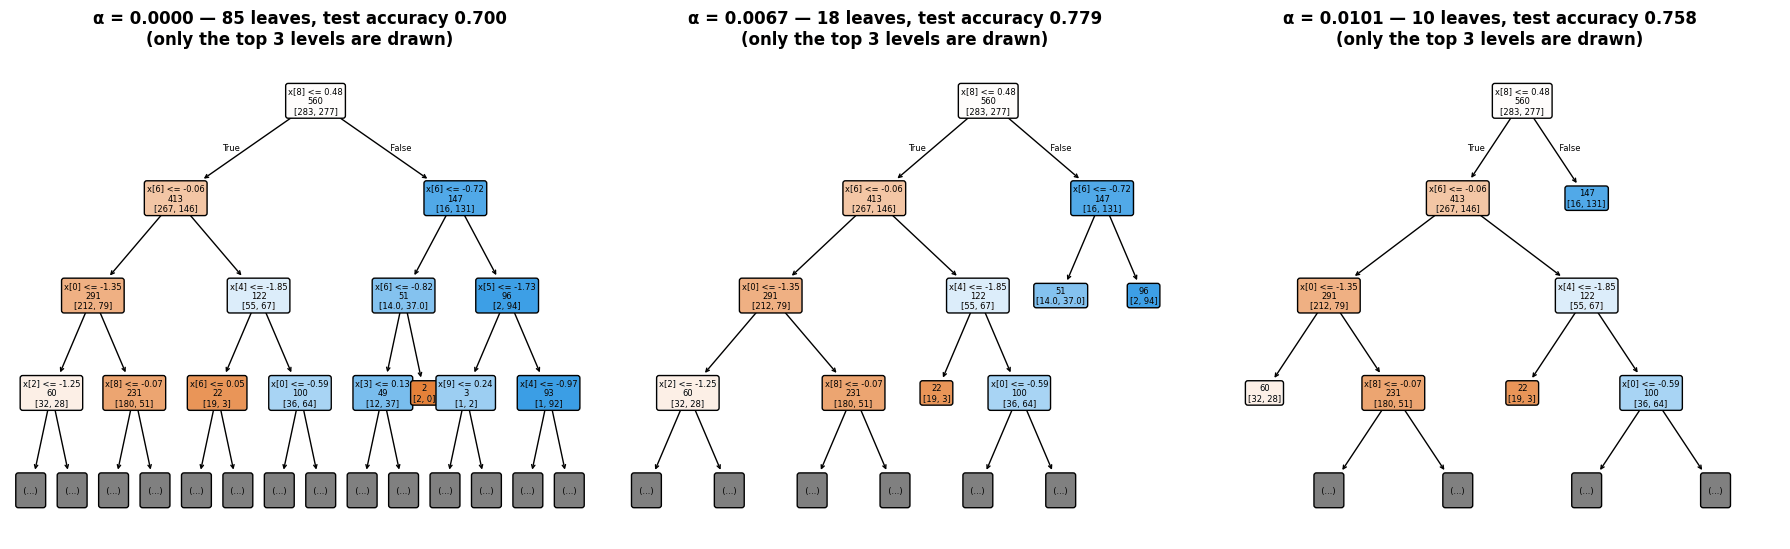

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.6))
for ax, a in zip(axes, [0.0, float(alpha_grid[best_i]), alpha_1se]):     # unpruned, CV-best, 1-SE rule
    m = DecisionTreeClassifier(ccp_alpha=a, random_state=RANDOM_STATE).fit(Xn_tr, yn_tr)
    # impurity=False hides the Gini values, max_depth=3 draws only the top 3 levels,
    # label="none" drops the field names ("samples =", "value =") and keeps just the numbers
    plot_tree(m, ax=ax, filled=True, rounded=True, impurity=False, max_depth=3, fontsize=6,
              precision=2, label="none")
    ax.set_title(f"α = {a:.4f} — {m.get_n_leaves()} leaves, test accuracy {m.score(Xn_te, yn_te):.3f}\n"
                 "(only the top 3 levels are drawn)")
plt.tight_layout()
plt.show()

## 7. Practical matters

### 7.1 No scaling, and robustness to monotone transforms

Section 2.2 argued this from the algorithm; here is the check. We exponentiate one feature,
shrink another by a factor of a million, and refit.

In [16]:
X_scaled_demo = Xn_tr.copy()                     # .copy(), so that the original training data stay untouched
X_scaled_demo[:, 0] = np.exp(X_scaled_demo[:, 0] / 2) * 1000          # a wild monotone transform
X_scaled_demo[:, 1] = X_scaled_demo[:, 1] * 1e-6                      # feature 1 shrunk by a factor of a million
t_plain = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE).fit(Xn_tr, yn_tr)
t_warped = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE).fit(X_scaled_demo, yn_tr)
# tree_.feature lists the feature each node splits on (-2 marks a leaf);
# np.array_equal(a, b) is True when both arrays have the same shape and the same values
print(f"identical split structure: {np.array_equal(t_plain.tree_.feature, t_warped.tree_.feature)}")
print(f"identical predictions:     {np.array_equal(t_plain.predict(Xn_tr), t_warped.predict(X_scaled_demo))}")

identical split structure: True
identical predictions:     True


The same tree, node for node: only the printed thresholds differ. Contrast this with
notebook 8, where forgetting to scale makes $k$NN useless, or notebook 7, where an unscaled
feature quietly dominates the penalty. It is one less thing to get wrong — and one less
reason to build a preprocessing pipeline, though you still want one for imputation and
encoding.

> **Real-life example.** A weather service predicts night frost from the evening temperature and
> the day's rainfall. Whether temperature is stored in °C or °F, and rainfall in millimetres or
> on a log scale, the tree asks the same questions ("below 3 °C?" is "below 37.4 °F?") and makes
> exactly the same predictions.

### 7.2 Missing values and categorical features

Since version 1.3 scikit-learn's trees handle `NaN` natively: at each split, missing values
are sent to whichever child gives the larger impurity decrease, learned from the data. No
imputation is required — although imputation plus a "was missing" indicator (notebook 4)
can still be better when the missingness is informative in a way a single split cannot
capture.

> **Real-life example.** On a used-car site the "date of last service" field is blank most often
> for cars that were never serviced. A tree predicting breakdowns can learn to send the blanks
> down the same branch as "serviced long ago", so the missingness itself becomes evidence,
> without anyone filling in a made-up date.

In [17]:
# e.g. values lost at random, as when a lab sample is dropped or a form field is skipped by accident
X_miss = Xn_tr.copy()
# rng.random(shape) draws uniform numbers in [0, 1); "< 0.15" is True for about 15 % of the cells, which become NaN
X_miss[rng.random(X_miss.shape) < 0.15] = np.nan                       # 15 % missing completely at random
X_miss_te = Xn_te.copy()
X_miss_te[rng.random(X_miss_te.shape) < 0.15] = np.nan                 # the test set gets its own random holes
miss_tree = DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE).fit(X_miss, yn_tr)   # NaN accepted as is
# first line: the same depth-6 tree fitted and scored on the complete data, for comparison
print(f"complete data      : test accuracy {DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE).fit(Xn_tr, yn_tr).score(Xn_te, yn_te):.3f}")
print(f"15 % values missing: test accuracy {miss_tree.score(X_miss_te, yn_te):.3f}  (no imputation)")

complete data      : test accuracy 0.775
15 % values missing: test accuracy 0.721  (no imputation)


Throwing away 15 % of every feature costs a few points of accuracy — as it should — but the
model still fits and still works, with no imputer and no error. That is a genuine
convenience on messy tabular data.

**Categorical features** are the weaker spot. scikit-learn's `DecisionTreeClassifier` only
splits numerically, so nominal categories must be one-hot encoded — which fragments a
$k$-level feature into $k$ weak binary questions and biases the tree against it. The
alternatives are ordinal encoding (acceptable only when the order is real),
`HistGradientBoostingClassifier(categorical_features=...)`, which splits on subsets of
categories natively (notebook 10), or `TargetEncoder` (notebook 4).

> **Real-life example.** A delivery company predicts late deliveries from, among other things,
> the postcode district, with 120 levels. One-hot encoding turns it into 120 yes/no questions
> about one district each, so the tree cannot simply ask "is it one of the 30 rural districts?";
> every district has to earn its own split from its own share of the data.

### 7.3 Feature importance, and why the built-in one lies

`feature_importances_` sums, over all nodes that split on a feature, the impurity decrease
weighted by the number of samples reaching the node, then normalises. It is free to compute
— and systematically biased. A feature with many distinct values offers many candidate
thresholds, so by chance alone one of them fits the noise better; the greedy search is drawn
to it (Strobl et al., 2007). The demonstration is brutal: give a tree one genuinely
informative *binary* feature and four pure-noise features of increasing cardinality.

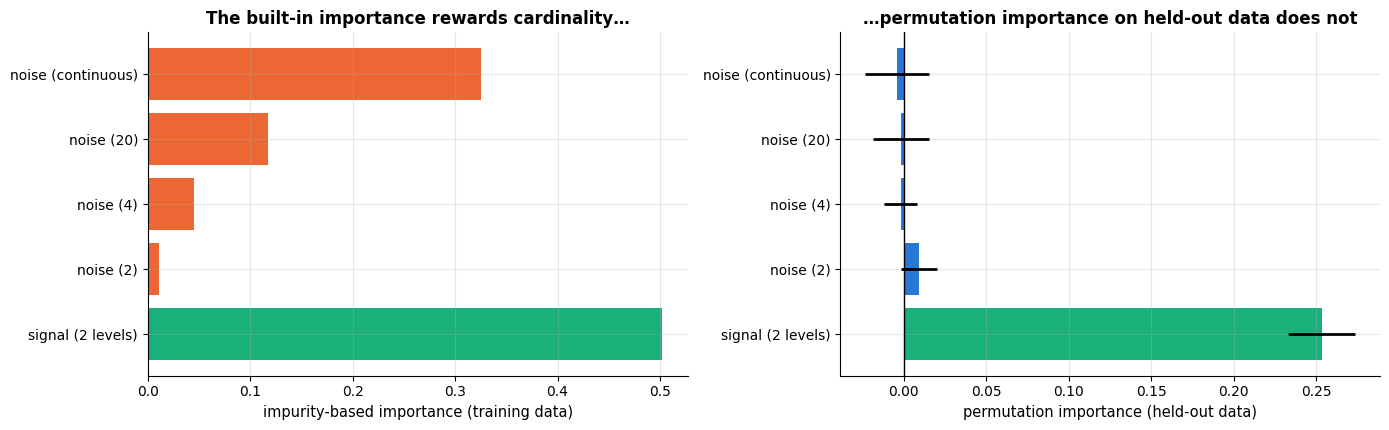

impurity-based:    {'signal (2 levels)': np.float64(0.502), 'noise (2)': np.float64(0.011), 'noise (4)': np.float64(0.045), 'noise (20)': np.float64(0.117), 'noise (continuous)': np.float64(0.325)}
permutation (test): {'signal (2 levels)': np.float64(0.253), 'noise (2)': np.float64(0.009), 'noise (4)': np.float64(-0.002), 'noise (20)': np.float64(-0.002), 'noise (continuous)': np.float64(-0.004)}


In [18]:
# permutation_importance(model, X, y, n_repeats=...) shuffles one feature's column at a time and measures how
# much the model's score drops; a feature the model really relies on causes a large drop
from sklearn.inspection import permutation_importance

# e.g. 1500 pupils: signal = missed more than 20 school days (yes/no), y_imp = failed the year; the noise
# columns stand for meaningless codes such as a classroom number (20 levels) or a pupil ID (all distinct)
n_imp = 1500
signal = rng.integers(0, 2, n_imp)                                     # 1500 random 0/1 values (high end exclusive)
y_imp = np.where(rng.random(n_imp) < 0.85, signal, 1 - signal)         # the label follows `signal` 85 % of the time
# np.column_stack puts the five 1-D arrays side by side as columns -> shape (1500, 5)
X_imp = np.column_stack([signal,
                         rng.integers(0, 2, n_imp),                    # noise, 2 levels
                         rng.integers(0, 4, n_imp),                    # noise, 4 levels
                         rng.integers(0, 20, n_imp),                   # noise, 20 levels
                         rng.normal(size=n_imp)])                      # noise, all values distinct
imp_names = ["signal (2 levels)", "noise (2)", "noise (4)", "noise (20)", "noise (continuous)"]
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(X_imp, y_imp, test_size=0.3, stratify=y_imp,
                                              random_state=RANDOM_STATE)
imp_tree = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(Xi_tr, yi_tr)      # unpruned
# every feature is shuffled 20 times in the TEST set; the result has .importances_mean and .importances_std
perm = permutation_importance(imp_tree, Xi_te, yi_te, n_repeats=20, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
# feature_importances_ is the impurity-based importance computed during fit (it sums to 1); the signal bar is green
axes[0].barh(imp_names, imp_tree.feature_importances_, color=[PALETTE[2]] + [PALETTE[1]] * 4)
axes[0].set_xlabel("impurity-based importance (training data)")
axes[0].set_title("The built-in importance rewards cardinality…")
# xerr adds horizontal error bars: ± one standard deviation over the 20 shuffles
axes[1].barh(imp_names, perm.importances_mean, xerr=perm.importances_std,
             color=[PALETTE[2]] + [PALETTE[0]] * 4)
axes[1].axvline(0, color="black", lw=1)
axes[1].set_xlabel("permutation importance (held-out data)")
axes[1].set_title("…permutation importance on held-out data does not")
plt.tight_layout()
plt.show()
# dict(zip(names, values)) pairs each feature name with its importance
print("impurity-based:   ", dict(zip(imp_names, imp_tree.feature_importances_.round(3))))
print("permutation (test):", dict(zip(imp_names, perm.importances_mean.round(3))))

The continuous noise feature collects a large share of the impurity-based importance even
though it carries no information whatsoever, and the ordering of the noise features follows
their cardinality exactly. Permutation importance, measured on *held-out* data, correctly
assigns them all approximately zero. **Never report `feature_importances_` without this
caveat**; notebook 17 develops permutation importance, partial dependence and SHAP properly.

> **Real-life example.** A school's tree predicting which pupils will fail the year can rank the
> pupil's ID number or the exact minute of enrolment (a different value for almost every pupil,
> and no real information) above a genuinely informative yes/no flag such as "missed more than
> 20 school days". A head teacher reading the built-in importances would conclude that ID
> numbers matter.

## 8. Instability: the variance of a single tree

Greedy, hierarchical fitting has a structural consequence: a small change in the data can
change the root split, and every split below it is then chosen on different data. Trees are
**high-variance** estimators. Let us see it, by fitting the same model to six bootstrap
resamples of the same training set.

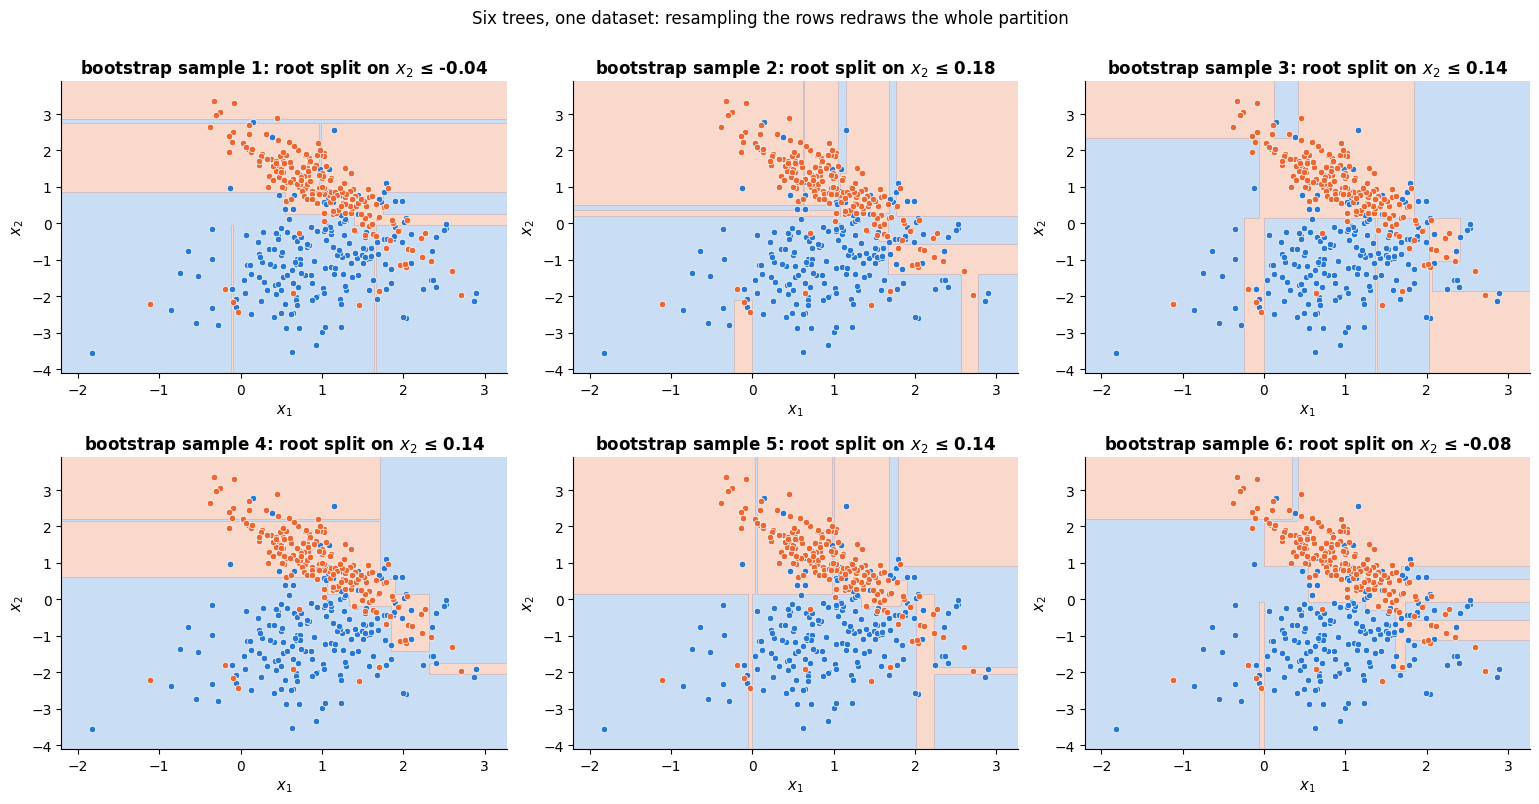

In [19]:
# 400 points in 2-D, one blob per class, with 10 % of the labels re-drawn at random
# e.g. two sensor readings of 400 machine parts, class 1 = failed inspection
X_var, y_var = make_classification(n_samples=400, n_features=2, n_redundant=0, n_informative=2,
                                   n_clusters_per_class=1, class_sep=1.0, flip_y=0.10,
                                   random_state=RANDOM_STATE)
fig, axes = plt.subplots(2, 3, figsize=(15.5, 8))
for k, ax in enumerate(axes.ravel()):            # axes is a 2 x 3 array; .ravel() flattens it into 6 panels
    # rng.choice(n, size, replace=True) draws `size` integers from 0..n-1 with repeats allowed
    idx = rng.choice(len(y_var), len(y_var), replace=True)             # a bootstrap sample
    m = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE).fit(X_var[idx], y_var[idx])
    # the boundary is drawn over all 400 points; tree_.feature[0] + 1 numbers the root's feature as 1 or 2
    plot_decision_boundary(m, X_var, y_var, ax=ax, feature_names=("$x_1$", "$x_2$"),
                           title=f"bootstrap sample {k + 1}: root split on "
                                 f"$x_{m.tree_.feature[0] + 1}$ ≤ {m.tree_.threshold[0]:.2f}")
    ax.legend().remove()
fig.suptitle("Six trees, one dataset: resampling the rows redraws the whole partition", y=1.0)
plt.tight_layout()
plt.show()

The root split lands in roughly the same place each time — that first question is estimated
from all 400 points and is fairly stable — but everything below it is redrawn: different
features, different thresholds, different slivers cut out of the corners. That is where a
tree's variance lives. Now measure it, and — the point of the exercise — measure what happens
when we *average* the trees instead of choosing one.

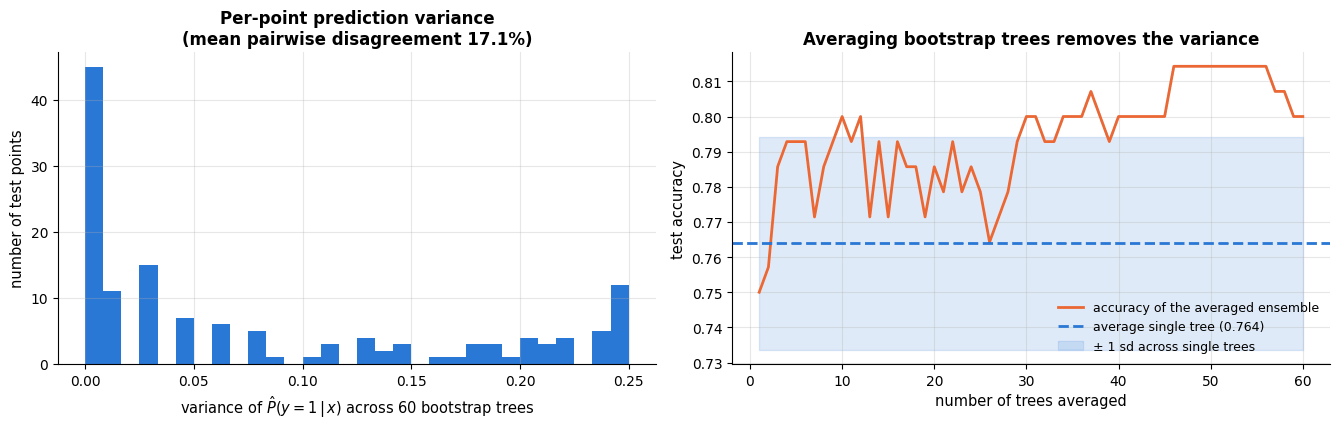

single unpruned tree: test accuracy 0.764 ± 0.030
average of 60 trees : test accuracy 0.800


In [20]:
Xv_tr, Xv_te, yv_tr, yv_te = train_test_split(X_var, y_var, test_size=0.35, stratify=y_var,
                                              random_state=RANDOM_STATE)
n_trees = 60
proba_stack = np.zeros((n_trees, len(yv_te)))    # row b: tree b's P(y = 1) for every test point
single_acc = np.zeros(n_trees)                   # the test accuracy of each tree on its own
for b in range(n_trees):
    idx = rng.choice(len(yv_tr), len(yv_tr), replace=True)       # a bootstrap sample of the training rows
    m = DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE).fit(Xv_tr[idx], yv_tr[idx])   # unpruned
    proba_stack[b] = m.predict_proba(Xv_te)[:, 1]                # predict_proba is (n_test, 2); [:, 1] = P(class 1)
    single_acc[b] = m.score(Xv_te, yv_te)

# for each b: average the probabilities of the first b + 1 trees, threshold at 0.5, compare with the true labels;
# .__eq__(yv_te) is "== yv_te" written as a method call, so the chain can continue with .mean() (the accuracy)
ensemble_acc = [( proba_stack[:b + 1].mean(axis=0) >= 0.5).astype(int).__eq__(yv_te).mean() for b in range(n_trees)]
# how often two trees predict different classes, averaged over all 66 pairs (i < j) among the first 12 trees;
# np.round turns each probability into a 0/1 prediction
pairwise_disagreement = np.mean([(np.round(proba_stack[i]) != np.round(proba_stack[j])).mean()
                                 for i in range(12) for j in range(i + 1, 12)])

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
axes[0].hist(proba_stack.var(axis=0), bins=30, color=PALETTE[0])     # .var(axis=0): variance across the 60 trees
axes[0].set_xlabel("variance of $\\hat{P}(y=1\\,|\\,x)$ across 60 bootstrap trees")
axes[0].set_ylabel("number of test points")
axes[0].set_title(f"Per-point prediction variance\n(mean pairwise disagreement {pairwise_disagreement:.1%})")
axes[1].plot(np.arange(1, n_trees + 1), ensemble_acc, lw=2, color=PALETTE[1],
             label="accuracy of the averaged ensemble")
axes[1].axhline(single_acc.mean(), color=PALETTE[0], ls="--", label=f"average single tree ({single_acc.mean():.3f})")
# a shaded band of ± one standard deviation around the average single-tree accuracy
axes[1].fill_between(np.arange(1, n_trees + 1), single_acc.mean() - single_acc.std(),
                     single_acc.mean() + single_acc.std(), color=PALETTE[0], alpha=0.15,
                     label="± 1 sd across single trees")
axes[1].set_xlabel("number of trees averaged")
axes[1].set_ylabel("test accuracy")
axes[1].set_title("Averaging bootstrap trees removes the variance")
axes[1].legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()
print(f"single unpruned tree: test accuracy {single_acc.mean():.3f} ± {single_acc.std():.3f}")
print(f"average of {n_trees} trees : test accuracy {ensemble_acc[-1]:.3f}")

> **Key idea.** A single deep tree has low bias and high variance. Averaging $B$ bootstrap
> trees leaves the bias alone and cuts the variance — from $\sigma^2$ towards
> $\rho\sigma^2$, where $\rho$ is the correlation between the trees. That single observation
> is the whole of **bagging** and **random forests**, and it is where notebook 10 starts.

## 9. Strengths, weaknesses and when to use a decision tree

| | |
|---|---|
| **Assumptions / inductive bias** | the target is well approximated by a piecewise-constant function on axis-aligned boxes; interactions are captured by nesting splits; nothing is assumed about scale, distribution or linearity |
| **Strengths** | fully interpretable (the model *is* the explanation); no scaling or distributional preprocessing; handles numeric and (with encoding) categorical features, missing values natively, and multi-output targets; captures interactions and non-linearity automatically; fast to train and extremely fast to predict; robust to irrelevant features and to outliers in $y$ for classification |
| **Weaknesses / failure modes** | **high variance** — a different sample gives a different tree (§8); **axis-aligned only** — an oblique boundary needs a staircase of many splits (§9.1); **cannot extrapolate** — predictions are flat outside the training range (§5.3); greedy fitting can miss a structure that a two-step lookahead would find (XOR-like targets need depth 2 to see anything); impurity-based importances are biased towards high-cardinality features (§7.3); piecewise-constant probabilities are coarse and poorly calibrated in deep trees (notebook 7) |
| **Data it suits** | tabular data of any $n$; mixed feature types; $d$ up to thousands, though a single tree uses at most $2^{\text{depth}}-1$ of them; moderate noise — heavy label noise causes severe overfitting unless pruned |
| **Complexity** | training $O(d\,n\log^2 n)$ for a balanced tree, prediction $O(\text{depth})$, memory $O(\text{nodes})$ |
| **Interpretability** | the highest of any model in this course: the full decision path for any prediction, the rule list, and the thresholds themselves are readable |
| **Use it when** | you need a model a human will audit, a fast rule-based classifier, a quick look at which features and interactions matter, or a base learner for an ensemble |
| **Avoid it when** | you need a smooth or extrapolating function, well-calibrated probabilities, a stable feature ranking, or the best possible accuracy — in which case use an ensemble (notebook 10), which keeps most of the advantages and drops most of the weaknesses |

### 9.1 Demonstrated failure: an oblique boundary

Every split is a cut perpendicular to one axis. A boundary that runs diagonally therefore has
to be approximated by a staircase — and each step costs a split, the data to justify it, and
variance. The experiment: generate a problem whose true boundary is $x_1 = 0$, then rotate
the whole cloud by $\theta$ and refit. The concept is *identical* at every angle; only the
coordinate system changes. A linear model is rotation-invariant; a tree is not.

> **Real-life example.** Doctors call an adult obese when the weight divided by the squared
> height (the BMI) is 30 or more. In the plane of height and weight that boundary is a sloping
> curve, so a tree given only height and weight needs a staircase of many height and weight
> thresholds to trace it; given the BMI as a feature, it needs a single split.

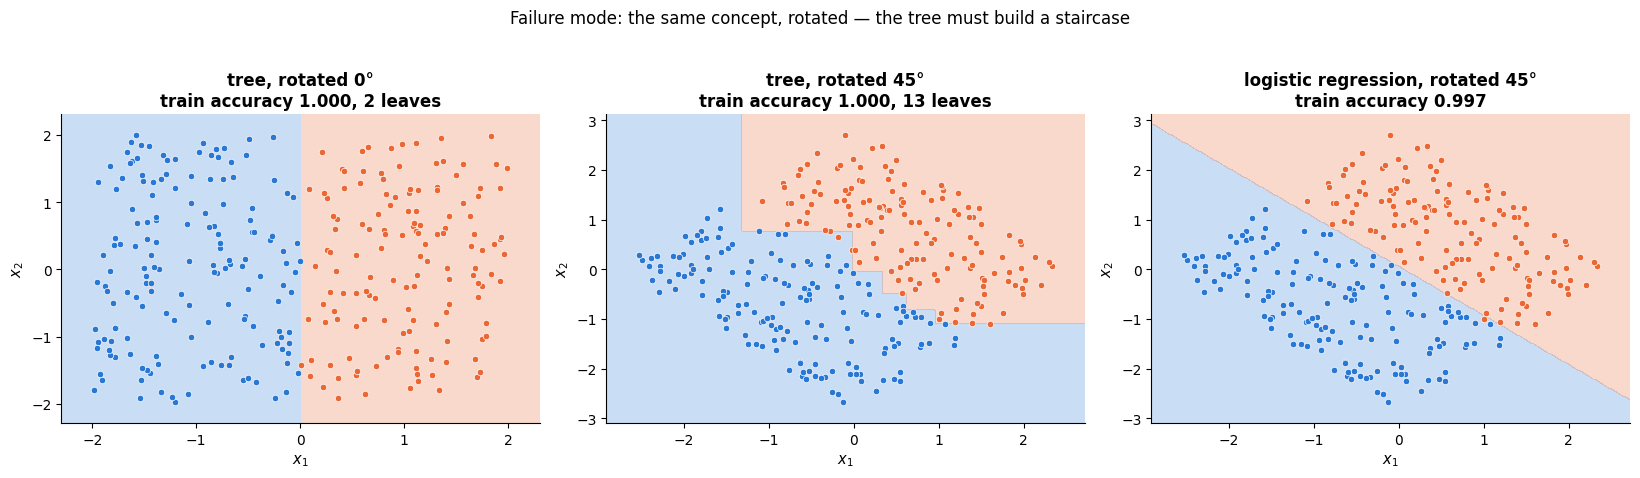

In [21]:
from sklearn.linear_model import LogisticRegression

# e.g. x1, x2 = standardised height and weight; once rotated, the class depends on both at once (like the BMI)
def rotated_problem(theta_deg, n=300, seed=RANDOM_STATE):
    """A problem whose true boundary is x1 = 0, rotated by theta degrees.

    Draws n points uniformly in the square [-2, 2] x [-2, 2], labels them 1 where x1 > 0 and 0
    elsewhere, then rotates the whole cloud (and the boundary with it) anticlockwise by theta_deg.
    The same seed gives the same points at every angle. Returns X of shape (n, 2) and y of shape (n,).
    """
    r = np.random.default_rng(seed)                  # a fresh local generator: the same points for every angle
    X = r.uniform(-2, 2, (n, 2))
    y = (X[:, 0] > 0).astype(int)                    # True/False -> 1/0
    theta = np.deg2rad(theta_deg)                    # degrees -> radians
    rot = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])   # 2 x 2 rotation matrix
    return X @ rot.T, y                              # the points are rows, so multiplying by rot.T rotates each one

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))
# each panel gets (rotation angle, model, name): a tree at 0°, a tree at 45°, logistic regression at 45°
for ax, (angle, model, name) in zip(axes, [(0, DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE), "tree"),
                                           (45, DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE), "tree"),
                                           (45, LogisticRegression(), "logistic regression")]):
    Xr, yr = rotated_problem(angle)
    model.fit(Xr, yr)
    # hasattr(obj, "name") is True if obj has that attribute; logistic regression has no leaves, so it gets ""
    leaves = f", {model.get_n_leaves()} leaves" if hasattr(model, "get_n_leaves") else ""
    plot_decision_boundary(model, Xr, yr, ax=ax, feature_names=("$x_1$", "$x_2$"),
                           title=f"{name}, rotated {angle}°\ntrain accuracy {model.score(Xr, yr):.3f}{leaves}")
    ax.legend().remove()
fig.suptitle("Failure mode: the same concept, rotated — the tree must build a staircase", y=1.03)
plt.tight_layout()
plt.show()

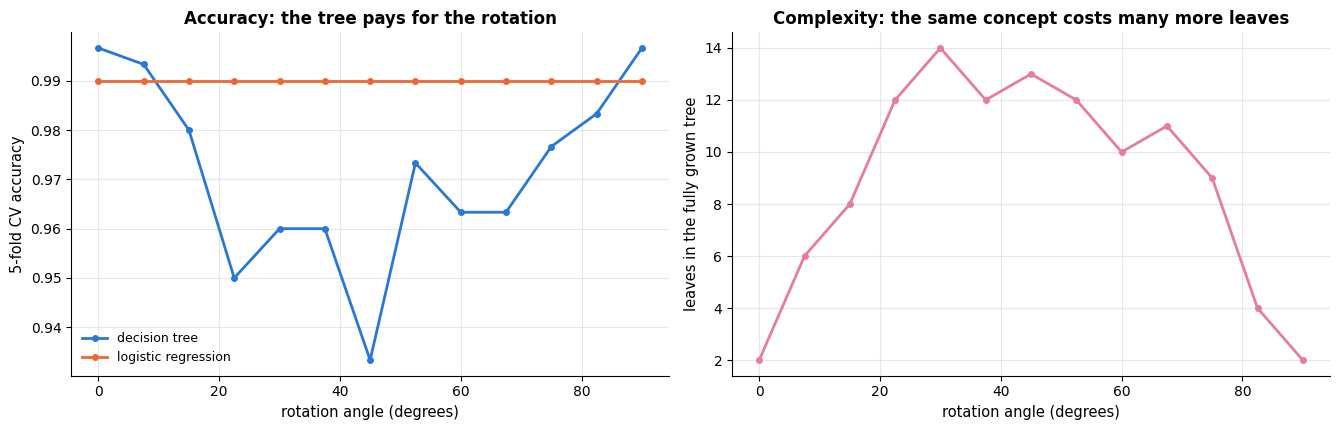

axis-aligned (0°): 2 leaves, CV accuracy 0.997
diagonal    (45°): 13 leaves, CV accuracy 0.933
logistic regression is unaffected: 0.990 – 0.990


In [22]:
angles = np.arange(0, 91, 7.5)                   # 0, 7.5, 15, ..., 90 degrees
tree_acc, lr_acc, tree_leaves = [], [], []
for angle in angles:
    Xr, yr = rotated_problem(angle)
    # mean 5-fold CV accuracy of a fully grown tree and of logistic regression on the same rotated data
    tree_acc.append(cross_val_score(DecisionTreeClassifier(random_state=RANDOM_STATE), Xr, yr, cv=cv5).mean())
    lr_acc.append(cross_val_score(LogisticRegression(), Xr, yr, cv=cv5).mean())
    tree_leaves.append(DecisionTreeClassifier(random_state=RANDOM_STATE).fit(Xr, yr).get_n_leaves())

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
axes[0].plot(angles, tree_acc, "-o", ms=4, color=PALETTE[0], label="decision tree")
axes[0].plot(angles, lr_acc, "-o", ms=4, color=PALETTE[1], label="logistic regression")
axes[0].set_xlabel("rotation angle (degrees)")
axes[0].set_ylabel("5-fold CV accuracy")
axes[0].set_title("Accuracy: the tree pays for the rotation")
axes[0].legend(fontsize=9)
axes[1].plot(angles, tree_leaves, "-o", ms=4, color=PALETTE[4])
axes[1].set_xlabel("rotation angle (degrees)")
axes[1].set_ylabel("leaves in the fully grown tree")
axes[1].set_title("Complexity: the same concept costs many more leaves")
plt.tight_layout()
plt.show()
print(f"axis-aligned (0°): {tree_leaves[0]} leaves, CV accuracy {tree_acc[0]:.3f}")
# the leaf count at the angle where the tree's CV accuracy is lowest (np.argmin), which is the 45° case
print(f"diagonal    (45°): {tree_leaves[int(np.argmin(tree_acc))]} leaves, CV accuracy {min(tree_acc):.3f}")
print(f"logistic regression is unaffected: {min(lr_acc):.3f} – {max(lr_acc):.3f}")

Two lessons. First, the tree's accuracy drops by several points while logistic regression's
is flat — the tree's inductive bias genuinely mismatches the problem. Second, and more
important, look at the *cost*: the axis-aligned version is solved by a tree with two leaves,
the rotated one needs six times as many. The tree does not fail loudly here; it fails
**expensively**, spending capacity (and therefore variance) on a boundary a linear model
draws with two numbers. If you suspect oblique structure, add rotated features (PCA,
notebook 14), use an oblique-split model, or use a linear model or SVM (notebook 11).

## 10. Tuning guide

| Hyper-parameter | Controls | Range / scale | Bias–variance | Default |
|---|---|---|---|---|
| `max_depth` | maximum number of nested questions | 1 … 20 (or `None`), **linear** | ↑ depth → ↓ bias, ↑ variance | `None` (grow fully) |
| `min_samples_leaf` | smallest allowed leaf | 1 … ~5 % of $n$, **log** | ↑ → smoother, ↑ bias | `1` |
| `ccp_alpha` | price of a leaf in post-pruning | $0$ … a few $\times 10^{-2}$, **log** | ↑ → smaller tree, ↑ bias | `0.0` |
| `min_samples_split` | smallest node that may be split | 2 … 50, log | mild version of `min_samples_leaf` | `2` |
| `max_leaf_nodes` | hard cap on leaves (best-first growth) | 2 … few hundred, log | direct size control | `None` |
| `criterion` | `"gini"` / `"log_loss"` (entropy) — `"squared_error"` etc. for regression | categorical | negligible | `"gini"` |
| `max_features` | features considered per split | 1 … $d$, or `"sqrt"` | ↓ → more randomness, ↓ variance (the key knob in *forests*) | `None` (all) |
| `class_weight` | per-class loss weight | `None` / `"balanced"` | shifts the leaves' majority votes | `None` |

**Tune in this order.**

1. **One size parameter first.** `max_depth`, `min_samples_leaf`, `max_leaf_nodes` and
   `ccp_alpha` all control the same thing — how big the tree is — so tuning all four is
   wasted budget with a real risk of overfitting the search (notebook 12). Pick **either**
   `ccp_alpha` (principled, one parameter, nested sequence) **or** the pair
   `max_depth` × `min_samples_leaf` (cheaper to interpret).
2. **`max_depth` and `min_samples_leaf` interact**: a large `min_samples_leaf` already stops
   growth early, so the best depth depends on it. If you tune both, tune them *jointly*
   (§10.3).
3. **`criterion`** last, and only to confirm it does not matter. It usually does not.
4. **`max_features`** is not really a single-tree parameter — it exists to decorrelate trees
   inside a forest (notebook 10). On a single tree it just adds variance.

### 10.1 The three size knobs

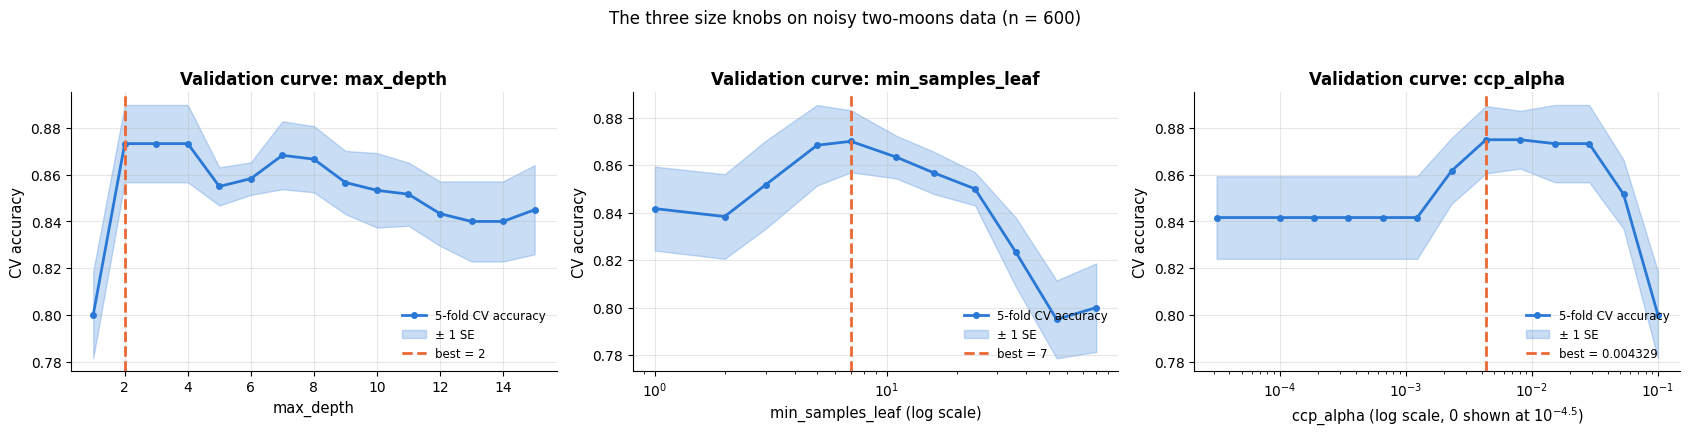

In [23]:
from sklearn.datasets import make_moons

# two interleaving half-circles ("moons"); noise=0.35 is the sd of the Gaussian noise added to every point
# e.g. two standardised soil readings of 600 fields, class 1 = crop disease found
X_tune, y_tune = make_moons(n_samples=600, noise=0.35, random_state=RANDOM_STATE)

def cv_curve(param, values, **fixed):
    """5-fold CV mean and standard error for one hyper-parameter.

    For every v in `values`, cross-validates DecisionTreeClassifier(param=v, **fixed) on the
    two-moons data (X_tune, y_tune) with the cv5 folds. **fixed collects any extra keyword
    arguments, which stay the same for every v (e.g. criterion="log_loss").
    Returns two arrays of length len(values): the mean CV accuracies and their standard errors.
    """
    means, ses = [], []
    for v in values:
        # **{param: v} passes a keyword argument whose name is held in the string `param`, e.g. max_depth=v
        scores = cross_val_score(DecisionTreeClassifier(**{param: v}, random_state=RANDOM_STATE, **fixed),
                                 X_tune, y_tune, cv=cv5)
        means.append(scores.mean())
        ses.append(scores.std(ddof=1) / np.sqrt(len(scores)))
    return np.array(means), np.array(ses)

depths = np.arange(1, 16)                                   # 1, 2, ..., 15
# 12 log-spaced sizes from 1 to 80, rounded to integers; np.unique removes the duplicates the rounding creates
leaf_sizes = np.unique(np.round(np.logspace(0, np.log10(80), 12)).astype(int))
alphas_tune = np.concatenate([[0.0], np.logspace(-4, -1, 12)])    # 0 (no pruning), then 12 values from 1e-4 to 0.1

fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
# one panel per knob: (parameter name, values to try, x-axis label, log x-axis?)
for ax, (param, values, xlabel, logx) in zip(axes, [
        ("max_depth", depths, "max_depth", False),
        ("min_samples_leaf", leaf_sizes, "min_samples_leaf (log scale)", True),
        ("ccp_alpha", alphas_tune, r"ccp_alpha (log scale, 0 shown at $10^{-4.5}$)", True)]):
    mean, se = cv_curve(param, values)
    # alpha = 0 cannot sit on a log axis, so it is drawn at 10**-4.5 instead (`a if condition else b` picks one)
    x_plot = np.where(values == 0, 10 ** -4.5, values) if param == "ccp_alpha" else values
    ax.plot(x_plot, mean, "-o", ms=4, color=PALETTE[0], label="5-fold CV accuracy")
    ax.fill_between(x_plot, mean - se, mean + se, alpha=0.25, color=PALETTE[0], label="± 1 SE")
    k = int(np.argmax(mean))
    # :.4g prints at most 4 significant digits and drops trailing zeros
    ax.axvline(x_plot[k], color=PALETTE[1], ls="--", label=f"best = {values[k]:.4g}")
    if logx:
        ax.set_xscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("CV accuracy")
    ax.set_title(f"Validation curve: {param}")
    ax.legend(fontsize=8.5, loc="lower right")
fig.suptitle("The three size knobs on noisy two-moons data (n = 600)", y=1.03)
plt.tight_layout()
plt.show()

### 10.2 `criterion` and `max_features`

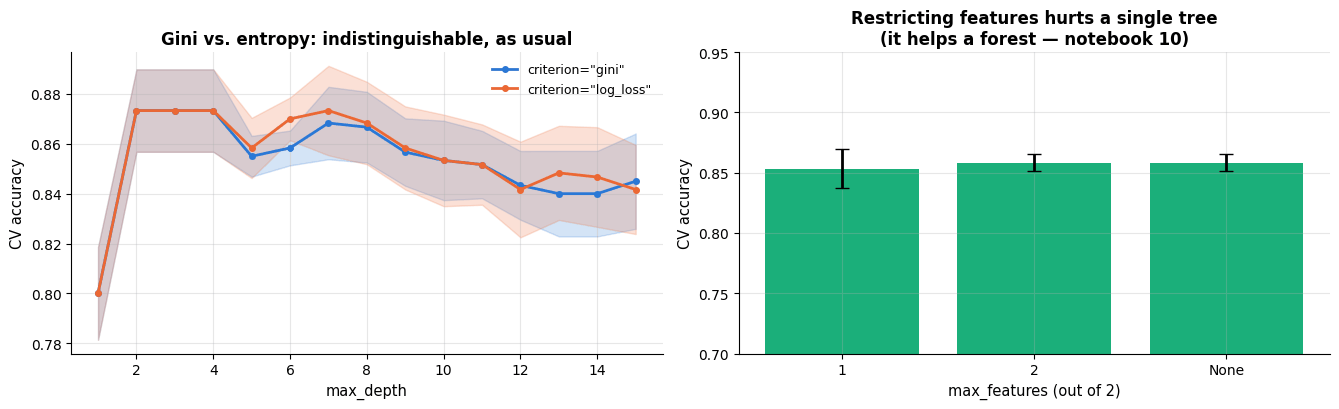

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))
# criterion="log_loss" splits on entropy (information gain); "gini" is the default
for crit, colour in [("gini", PALETTE[0]), ("log_loss", PALETTE[1])]:
    mean, se = cv_curve("max_depth", depths, criterion=crit)      # criterion reaches the tree through **fixed
    axes[0].plot(depths, mean, "-o", ms=4, color=colour, label=f'criterion="{crit}"')
    axes[0].fill_between(depths, mean - se, mean + se, alpha=0.2, color=colour)
axes[0].set_xlabel("max_depth")
axes[0].set_ylabel("CV accuracy")
axes[0].set_title("Gini vs. entropy: indistinguishable, as usual")
axes[0].legend(fontsize=9)

# max_features = how many randomly chosen features each split may consider (None = all of them)
feature_opts = [1, 2, None]
# despite its name, mean_mf holds one array of 5 fold scores per max_features option; the means are taken below
mean_mf = [cross_val_score(DecisionTreeClassifier(max_depth=6, max_features=mf, random_state=RANDOM_STATE),
                           X_tune, y_tune, cv=cv5) for mf in feature_opts]
# bar heights are the mean scores, yerr their standard errors; capsize draws small caps on the error bars
axes[1].bar([str(mf) for mf in feature_opts], [s.mean() for s in mean_mf],
            yerr=[s.std(ddof=1) / np.sqrt(len(s)) for s in mean_mf], color=PALETTE[2], capsize=5)
axes[1].set_ylim(0.7, 0.95)
axes[1].set_xlabel("max_features (out of 2)")
axes[1].set_ylabel("CV accuracy")
axes[1].set_title("Restricting features hurts a single tree\n(it helps a forest — notebook 10)")
plt.tight_layout()
plt.show()

### 10.3 The interacting pair: `max_depth` × `min_samples_leaf`

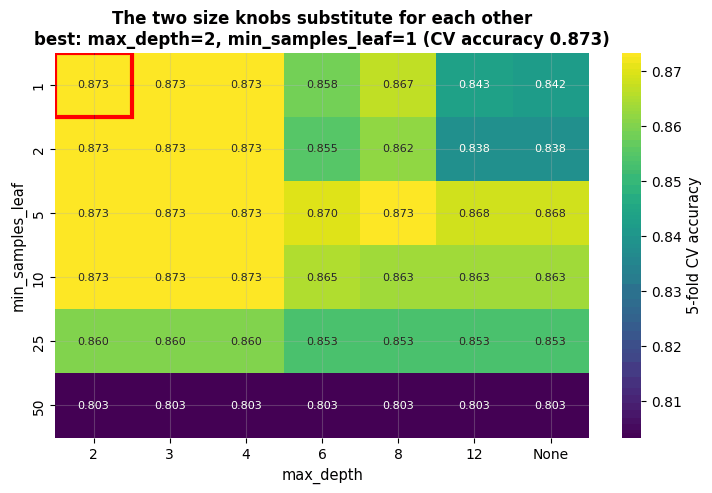

In [25]:
depth_axis = [2, 3, 4, 6, 8, 12, None]          # the heat-map's columns
leaf_axis = [1, 2, 5, 10, 25, 50]               # the heat-map's rows
heat = np.zeros((len(leaf_axis), len(depth_axis)))     # (6, 7): heat[i, j] = CV accuracy for leaf_axis[i], depth_axis[j]
for i, leaf in enumerate(leaf_axis):
    for j, depth in enumerate(depth_axis):
        heat[i, j] = cross_val_score(DecisionTreeClassifier(max_depth=depth, min_samples_leaf=leaf,
                                                            random_state=RANDOM_STATE),
                                     X_tune, y_tune, cv=cv5).mean()

fig, ax = plt.subplots(figsize=(8.6, 5))
# sns.heatmap draws a 2-D array as coloured cells; annot=True writes each value in its cell using fmt=".3f",
# annot_kws styles that text and cbar_kws passes options (here a label) to the colour bar
sns.heatmap(heat, ax=ax, cmap="viridis", annot=True, fmt=".3f", annot_kws={"size": 8},
            xticklabels=[str(d) for d in depth_axis], yticklabels=[str(l) for l in leaf_axis],
            cbar_kws={"label": "5-fold CV accuracy"})
# heat.argmax() is a position in the flattened array; np.unravel_index turns it back into (row, column)
i_best, j_best = np.unravel_index(heat.argmax(), heat.shape)
# outline the best cell: in a seaborn heat-map, cell (i, j) spans x from j to j + 1 and y from i to i + 1
ax.add_patch(plt.Rectangle((j_best, i_best), 1, 1, fill=False, edgecolor="red", lw=3))
ax.set_xlabel("max_depth")
ax.set_ylabel("min_samples_leaf")
ax.set_title(f"The two size knobs substitute for each other\n"
             f"best: max_depth={depth_axis[j_best]}, min_samples_leaf={leaf_axis[i_best]} "
             f"(CV accuracy {heat.max():.3f})")
plt.show()

Read the block structure. In the left-hand columns the depth cap already makes the tree small,
so `min_samples_leaf` changes nothing — the cells are identical. In the right-hand columns
the depth is unrestricted and the *leaf size* has to do the work: with `min_samples_leaf=1`
the score drops, with `min_samples_leaf=5` an unbounded tree is as good as a depth-2 one. The
worst cells are exactly those where neither brake is applied, and the bottom row shows what
happens when one is applied far too hard. The two knobs **substitute** for each other, which
is why tuning both is rarely worth the budget: pick one and search it properly.

### 10.4 What the knobs do to the fitted tree

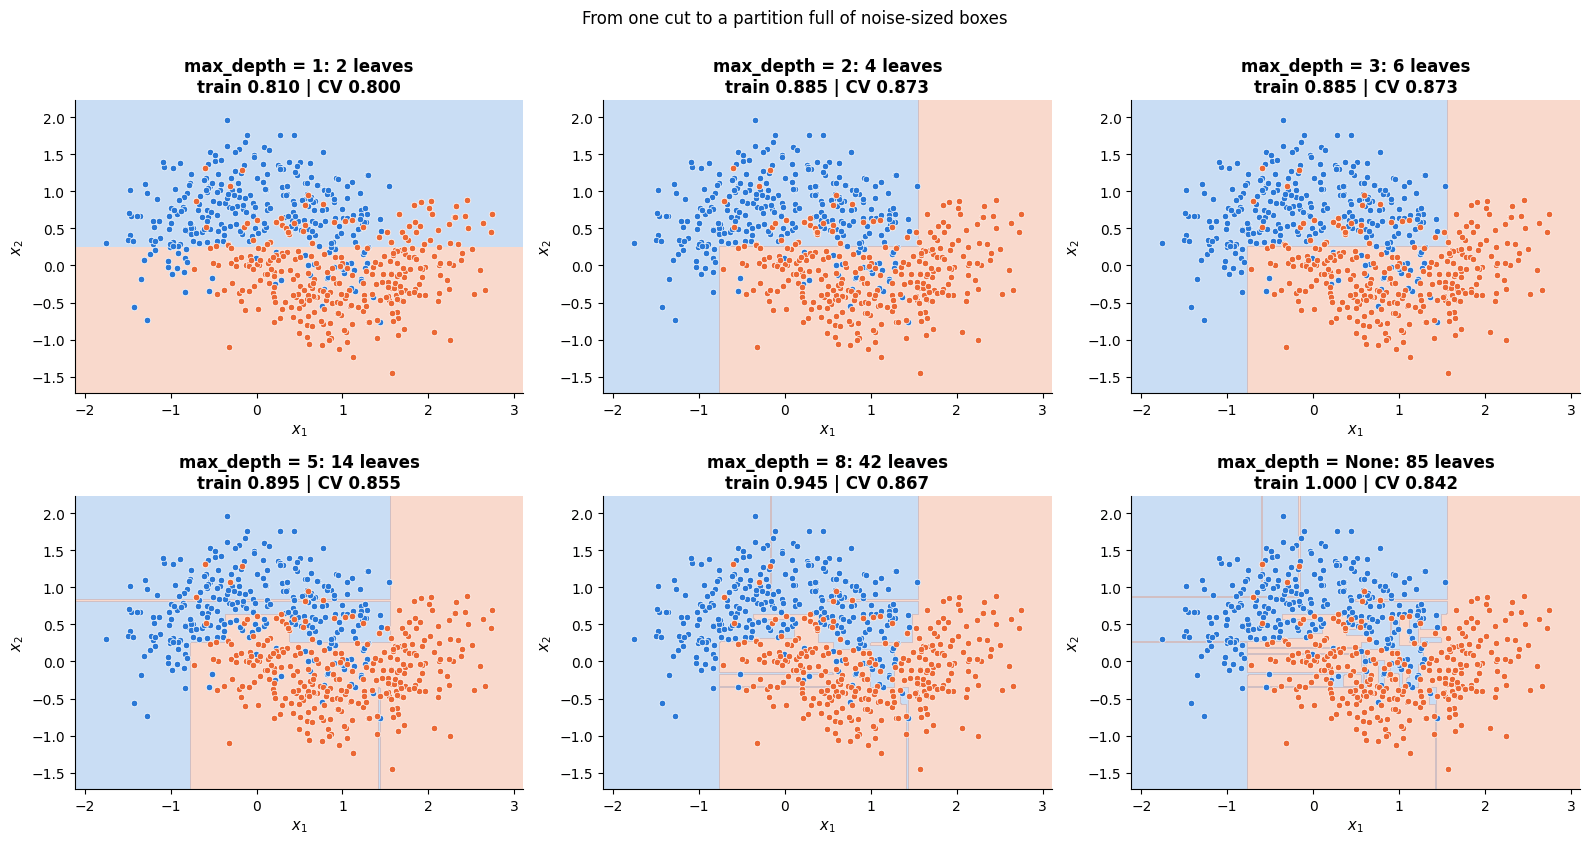

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8.4))
for ax, depth in zip(axes.ravel(), [1, 2, 3, 5, 8, None]):
    # one tree fitted on all the data for the picture, plus a separate 5-fold CV estimate of its accuracy
    m = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE).fit(X_tune, y_tune)
    cv_acc = cross_val_score(DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE),
                             X_tune, y_tune, cv=cv5).mean()
    plot_decision_boundary(m, X_tune, y_tune, ax=ax, feature_names=("$x_1$", "$x_2$"),
                           title=f"max_depth = {depth}: {m.get_n_leaves()} leaves\n"
                                 f"train {m.score(X_tune, y_tune):.3f} | CV {cv_acc:.3f}")
    ax.legend().remove()
fig.suptitle("From one cut to a partition full of noise-sized boxes", y=1.0)
plt.tight_layout()
plt.show()

### 10.5 Practical notes

- **Best value at the edge of the grid?** If the best `max_depth` is the largest you tried,
  extend the grid — but check the leaf count first: on noisy data an unbounded tree is
  almost never the CV winner, and a best-at-the-edge result usually means the problem is
  nearly noise-free.
- **Flat curve?** Apply the one-standard-error rule and take the *smaller* tree. Tree
  validation curves are unusually flat on their right-hand side, because extra depth is
  spent on tiny leaves that affect few predictions.
- **Runtime.** All of these parameters are cheap: a tree fit is $O(d\,n\log^2 n)$ and
  scikit-learn's implementation is fast. `ccp_alpha` is the cheapest of all if you compute
  the pruning path once and reuse the nested subtrees.
- **Not worth tuning:** `criterion`, `splitter`, `min_weight_fraction_leaf`, and
  `max_features` on a single tree. `min_impurity_decrease` is occasionally useful as a direct
  cousin of `ccp_alpha`.
- **A caution worth more than all of the above:** if you find yourself carefully tuning five
  parameters of a single tree to squeeze out accuracy, you want a random forest or gradient
  boosting (notebook 10), which will beat your best tuned tree with default settings.

## 11. Case study: wine cultivars, and a regression tree on diabetes

Both datasets are **real** — chemical assays and clinical measurements, not simulators.

### 11.1 Classifying wine cultivars

The wine data (Forina et al., via the UCI repository; bundled with scikit-learn) records 13
chemical measurements — alcohol, flavanoids, colour intensity, proline and so on — for 178
wines from three cultivars grown in the same Italian region. The question a producer would
ask: *which measurements identify the cultivar, and can we state the rule in a sentence?*
That is a question about interpretability. It is worth knowing in advance that a linear model
will score higher here — the classes are nearly linearly separable in these 13 chemical
variables — so the tree has to earn its place with the rule it produces, not with accuracy.

In [27]:
from sklearn.dummy import DummyClassifier          # baseline models that ignore the features
from sklearn.metrics import ConfusionMatrixDisplay, classification_report     # used in the next two cells
from sklearn.pipeline import make_pipeline         # chains steps into one model: here scaling, then the classifier
from sklearn.preprocessing import StandardScaler   # rescales every feature to mean 0 and standard deviation 1

# hold out 25 % of the wines as a test set, with the same class proportions in both parts (stratify)
Xw_tr, Xw_te, yw_tr, yw_te = train_test_split(wine.data, wine.target, test_size=0.25,
                                              stratify=wine.target, random_state=RANDOM_STATE)
print(f"{wine.data.shape[0]} wines, {wine.data.shape[1]} features, classes {np.bincount(wine.target)}")  # wines per class
# the linear model needs standardised features (notebook 7, §3.1); the tree does not
# DummyClassifier(strategy="most_frequent") always predicts the most common class: the score to beat
for name, model in [("majority-class dummy", DummyClassifier(strategy="most_frequent")),
                    ("tree, default (unpruned)", DecisionTreeClassifier(random_state=RANDOM_STATE)),
                    ("logistic regression (notebook 7)", make_pipeline(StandardScaler(),
                                                                       LogisticRegression(max_iter=2000)))]:
    s = cross_val_score(model, Xw_tr, yw_tr, cv=cv5)
    # {name:34s} pads the name to 34 characters so the columns line up; the ± value is the standard error
    print(f"{name:34s} CV accuracy {s.mean():.3f} ± {s.std(ddof=1) / np.sqrt(len(s)):.3f}")

178 wines, 13 features, classes [59 71 48]
majority-class dummy               CV accuracy 0.399 ± 0.009
tree, default (unpruned)           CV accuracy 0.903 ± 0.028
logistic regression (notebook 7)   CV accuracy 0.977 ± 0.009


Now tune with the guide from section 10: compute the pruning path, cross-validate over it,
and apply the one-standard-error rule.

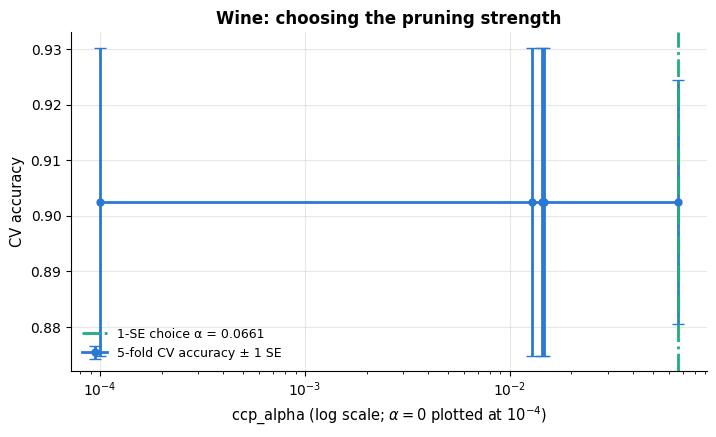

CV-best    α=0.0000  8 leaves, depth 4  TEST accuracy 0.956
1-SE rule  α=0.0661  3 leaves, depth 2  TEST accuracy 0.867
(the two differ by 4 wines out of 45; the standard error of either accuracy is about ±0.045)
              precision    recall  f1-score   support

     class_0      1.000     0.933     0.966        15
     class_1      0.900     1.000     0.947        18
     class_2      1.000     0.917     0.957        12

    accuracy                          0.956        45
   macro avg      0.967     0.950     0.956        45
weighted avg      0.960     0.956     0.956        45



In [28]:
# fit an unpruned tree and compute its pruning path in one chained expression
wine_path = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(Xw_tr, yw_tr).cost_complexity_pruning_path(Xw_tr, yw_tr)
wine_alphas = wine_path.ccp_alphas[:-1]                  # drop the last alpha (the root-only tree)
wine_mean, wine_se = [], []
for a in wine_alphas:                                    # cross-validate every alpha of the path, as in section 6.3
    s = cross_val_score(DecisionTreeClassifier(ccp_alpha=a, random_state=RANDOM_STATE), Xw_tr, yw_tr, cv=cv5)
    wine_mean.append(s.mean())
    wine_se.append(s.std(ddof=1) / np.sqrt(len(s)))
wine_mean, wine_se = np.array(wine_mean), np.array(wine_se)
k_best = int(np.argmax(wine_mean))
# one-SE rule: the largest alpha whose CV mean is within one standard error of the best
alpha_wine = float(wine_alphas[np.flatnonzero(wine_mean >= wine_mean[k_best] - wine_se[k_best])[-1]])

fig, ax = plt.subplots(figsize=(8.2, 4.4))
# errorbar draws points with vertical error bars (yerr); np.maximum moves alpha = 0 to 1e-4 so the log axis can show it
ax.errorbar(np.maximum(wine_alphas, 1e-4), wine_mean, yerr=wine_se, fmt="-o", ms=5, capsize=4,
            color=PALETTE[0], label="5-fold CV accuracy ± 1 SE")
ax.axvline(max(alpha_wine, 1e-4), color=PALETTE[2], ls="-.", label=f"1-SE choice α = {alpha_wine:.4f}")
ax.set_xscale("log")
ax.set_xlabel(r"ccp_alpha (log scale; $\alpha=0$ plotted at $10^{-4}$)")
ax.set_ylabel("CV accuracy")
ax.set_title("Wine: choosing the pruning strength")
ax.legend(fontsize=9, loc="lower left")
plt.show()

# refit on the whole training split, once with the CV-best alpha and once with the 1-SE alpha
wine_best = DecisionTreeClassifier(ccp_alpha=float(wine_alphas[k_best]), random_state=RANDOM_STATE).fit(Xw_tr, yw_tr)
wine_simple = DecisionTreeClassifier(ccp_alpha=alpha_wine, random_state=RANDOM_STATE).fit(Xw_tr, yw_tr)
se_test = np.sqrt(0.9 * 0.1 / len(yw_te))                 # binomial SE of an accuracy near 0.9 on 45 wines
for label, m in [("CV-best", wine_best), ("1-SE rule", wine_simple)]:
    # m.ccp_alpha reads back the hyper-parameter; get_depth() is the depth of the fitted tree
    print(f"{label:10s} α={m.ccp_alpha:.4f}  {m.get_n_leaves()} leaves, depth {m.get_depth()}  "
          f"TEST accuracy {m.score(Xw_te, yw_te):.3f}")
# accuracy difference x number of test wines = how many more wines the CV-best tree classifies correctly
n_diff = int(round((wine_best.score(Xw_te, yw_te) - wine_simple.score(Xw_te, yw_te)) * len(yw_te)))
print(f"(the two differ by {n_diff} wines out of {len(yw_te)}; the standard error of either accuracy is about ±{se_test:.3f})")
# classification_report: precision, recall, F1 and support (number of true cases) for every class, with 3 decimals
print(classification_report(yw_te, wine_best.predict(Xw_te), target_names=list(wine.target_names), digits=3))

Cross-validation cannot separate the two — the curve is flat, because the wine problem is
easy and even the *unpruned* tree has only eight leaves, so the 1-SE rule reaches all the way
down to three. On the test set the larger tree is four wines better, roughly two standard
errors: suggestive, but not decisive on 45 wines. The honest framing is therefore not "which
is more accurate?" but "what do I need?" — the eight-leaf tree if the model is going to be
deployed, the three-leaf rule if a person is going to apply it by hand.

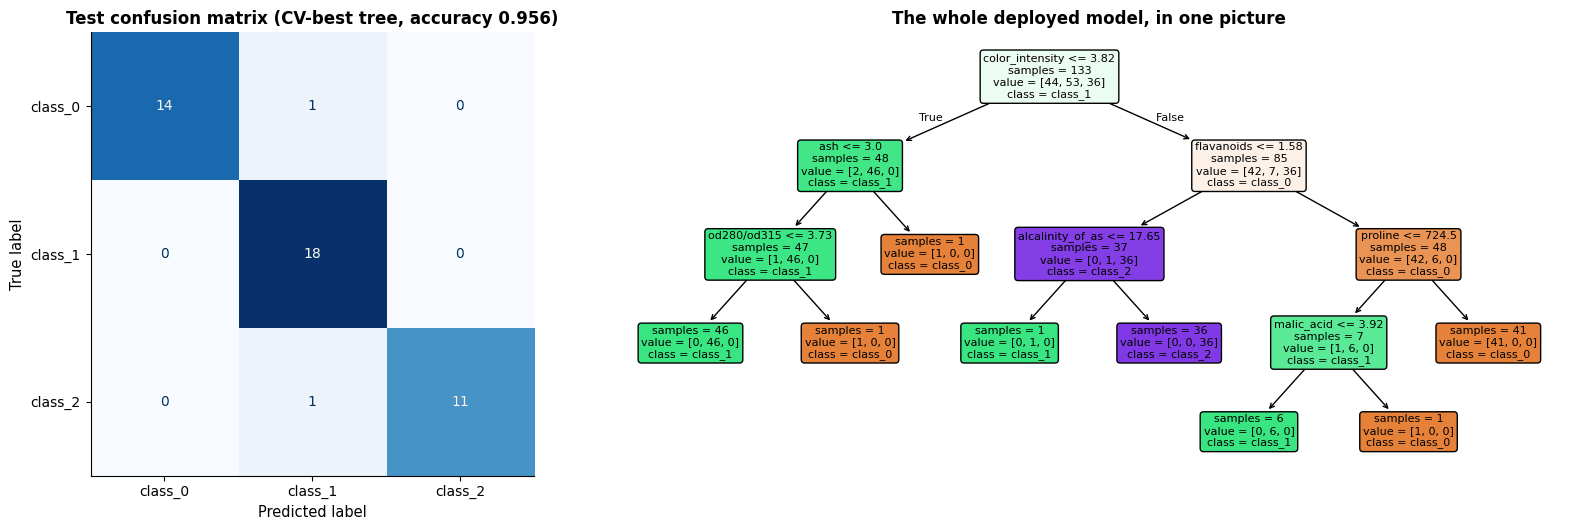

The three-leaf rule you could put on a business card:
|--- color_intensity <= 3.82
|   |--- class: 1
|--- color_intensity >  3.82
|   |--- flavanoids <= 1.58
|   |   |--- class: 2
|   |--- flavanoids >  1.58
|   |   |--- class: 0



In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16.5, 5.4), gridspec_kw={"width_ratios": [1, 1.6]})   # right panel wider
# ConfusionMatrixDisplay.from_estimator predicts on (X, y) and draws the confusion matrix (rows = true class,
# columns = predicted class); values_format="d" prints whole numbers and colorbar=False omits the colour scale
ConfusionMatrixDisplay.from_estimator(wine_best, Xw_te, yw_te, display_labels=list(wine.target_names),
                                      cmap="Blues", colorbar=False, ax=axes[0], values_format="d")
axes[0].set_title(f"Test confusion matrix (CV-best tree, accuracy {wine_best.score(Xw_te, yw_te):.3f})")
axes[0].grid(False)
plot_tree(wine_best, ax=axes[1], filled=True, rounded=True, fontsize=8, precision=2,
          feature_names=short_names, class_names=list(wine.target_names), impurity=False)
axes[1].set_title("The whole deployed model, in one picture")
plt.tight_layout()
plt.show()
print("The three-leaf rule you could put on a business card:")
print(export_text(wine_simple, feature_names=list(wine.feature_names), decimals=2))

Look at the root split, and then look back at the depth-3 tree of section 4. That tree, fitted
on all 178 wines, asked about **proline** first; these, fitted on the 133-wine training split,
ask about **colour intensity**. Same data source, 45 rows fewer, a different first question —
section 8's instability, live.

**What we would tell the producer.** A handful of routine assays — colour intensity and
flavanoid content first, then two or three more — place 43 of 45 held-out wines in the right
cultivar, and the whole model fits on one page. Three caveats belong in the same breath. The
two-question version is noticeably weaker (39 of 45), so the extra measurements are worth
taking if the distinction carries money. The thresholds come from 133 wines of one region and one
harvest and must be re-estimated elsewhere. And the *specific* rule is not stable — a
different sample of wines yields a different, equally accurate rule, so the message is
"these assays carry the signal", not "3.82 is a magic number". If accuracy mattered more than
the rule, a random forest (notebook 10) would do better still, at the cost of the page you
could hand over.

### 11.2 A regression tree on the diabetes data

The diabetes data (Efron, Hastie, Johnstone & Tibshirani, 2004) records ten baseline
variables for 442 patients and a quantitative measure of disease progression one year later.
Notebook 6 fitted linear models to it; here we ask what a tree adds — and what it costs. The
answer is instructive precisely because it is not flattering.

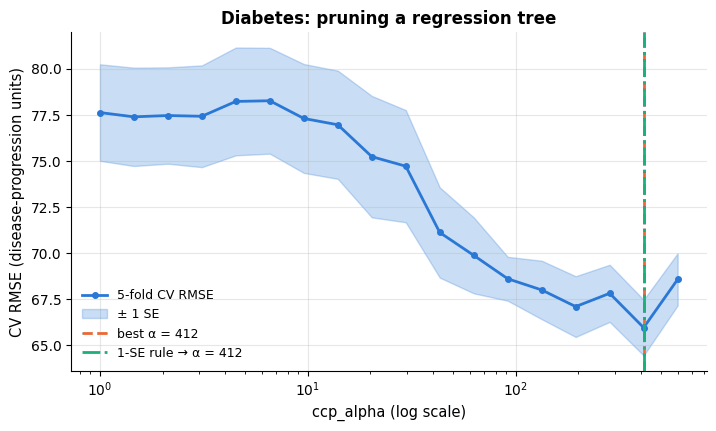

unpruned tree: 324 leaves, CV RMSE 77.8
pruned at α=412: 3 leaves, CV RMSE 66.0


,test RMSE,test R²,leaves
model,,,
mean baseline,74.881,-0.014,NaN
linear regression (notebook 6),53.370,0.485,NaN
"tree, unpruned",77.082,-0.075,324.0
"tree, pruned (α=412)",60.196,0.345,3.0


In [30]:
from sklearn.datasets import load_diabetes
from sklearn.dummy import DummyRegressor
# root_mean_squared_error(y_true, y_pred) is the RMSE; r2_score is the coefficient of determination R²
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import KFold          # plain k-fold splits (no stratification for a numeric target)

diabetes = load_diabetes()                          # .data is (442, 10), already centred and scaled; .target numeric
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(diabetes.data, diabetes.target, test_size=0.25,
                                              random_state=RANDOM_STATE)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

reg_alphas = np.logspace(0, np.log10(600), 18)      # a log grid spanning the whole pruning path
reg_mean, reg_se = [], []
for a in reg_alphas:
    # scikit-learn scorers follow "higher is better", so the RMSE comes back negated; the leading minus undoes that
    s = -cross_val_score(DecisionTreeRegressor(ccp_alpha=a, random_state=RANDOM_STATE), Xd_tr, yd_tr,
                         cv=kf, scoring="neg_root_mean_squared_error")
    reg_mean.append(s.mean())
    reg_se.append(s.std(ddof=1) / np.sqrt(len(s)))
reg_mean, reg_se = np.array(reg_mean), np.array(reg_se)
k = int(np.argmin(reg_mean))                        # lowest CV RMSE: for an error, smaller is better
# one-SE rule for an error: the largest alpha whose RMSE is at most one SE above the best
alpha_reg = float(reg_alphas[np.flatnonzero(reg_mean <= reg_mean[k] + reg_se[k])[-1]])

fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.plot(reg_alphas, reg_mean, "-o", ms=4, color=PALETTE[0], label="5-fold CV RMSE")
ax.fill_between(reg_alphas, reg_mean - reg_se, reg_mean + reg_se, alpha=0.25, color=PALETTE[0], label="± 1 SE")
ax.axvline(reg_alphas[k], color=PALETTE[1], ls="--", label=f"best α = {reg_alphas[k]:.0f}")
ax.axvline(alpha_reg, color=PALETTE[2], ls="-.", label=f"1-SE rule → α = {alpha_reg:.0f}")
ax.set_xscale("log")
ax.set_xlabel(r"ccp_alpha (log scale)")
ax.set_ylabel("CV RMSE (disease-progression units)")
ax.set_title("Diabetes: pruning a regression tree")
ax.legend(fontsize=9)
plt.show()
# the unpruned tree's leaf count and mean CV RMSE, both computed inline
print(f"unpruned tree: {DecisionTreeRegressor(random_state=RANDOM_STATE).fit(Xd_tr, yd_tr).get_n_leaves()} leaves, "
      f"CV RMSE {(-cross_val_score(DecisionTreeRegressor(random_state=RANDOM_STATE), Xd_tr, yd_tr, cv=kf, scoring='neg_root_mean_squared_error')).mean():.1f}")
# reg_alphas == alpha_reg finds the grid position of the chosen alpha, to look up its CV RMSE
print(f"pruned at α={alpha_reg:.0f}: "
      f"{DecisionTreeRegressor(ccp_alpha=alpha_reg, random_state=RANDOM_STATE).fit(Xd_tr, yd_tr).get_n_leaves()} leaves, "
      f"CV RMSE {reg_mean[np.flatnonzero(reg_alphas == alpha_reg)[0]]:.1f}")

tree_reg = DecisionTreeRegressor(ccp_alpha=alpha_reg, random_state=RANDOM_STATE).fit(Xd_tr, yd_tr)
comparison = []
# DummyRegressor(strategy="mean") always predicts the mean of the training targets: the baseline
for name, model in [("mean baseline", DummyRegressor(strategy="mean")),
                    ("linear regression (notebook 6)", LinearRegression()),
                    ("tree, unpruned", DecisionTreeRegressor(random_state=RANDOM_STATE)),
                    (f"tree, pruned (α={alpha_reg:.0f})", DecisionTreeRegressor(ccp_alpha=alpha_reg,
                                                                                random_state=RANDOM_STATE))]:
    model.fit(Xd_tr, yd_tr)
    pred = model.predict(Xd_te)
    # getattr(model, "get_n_leaves", default) returns the model's method if it has one, otherwise the default
    # lambda; calling the result with () gives the leaf count, or NaN for the models that are not trees
    comparison.append({"model": name, "test RMSE": root_mean_squared_error(yd_te, pred),
                       "test R²": r2_score(yd_te, pred),
                       "leaves": getattr(model, "get_n_leaves", lambda: np.nan)()})
pd.DataFrame(comparison).set_index("model").round(3)     # set_index("model") uses the model names as row labels

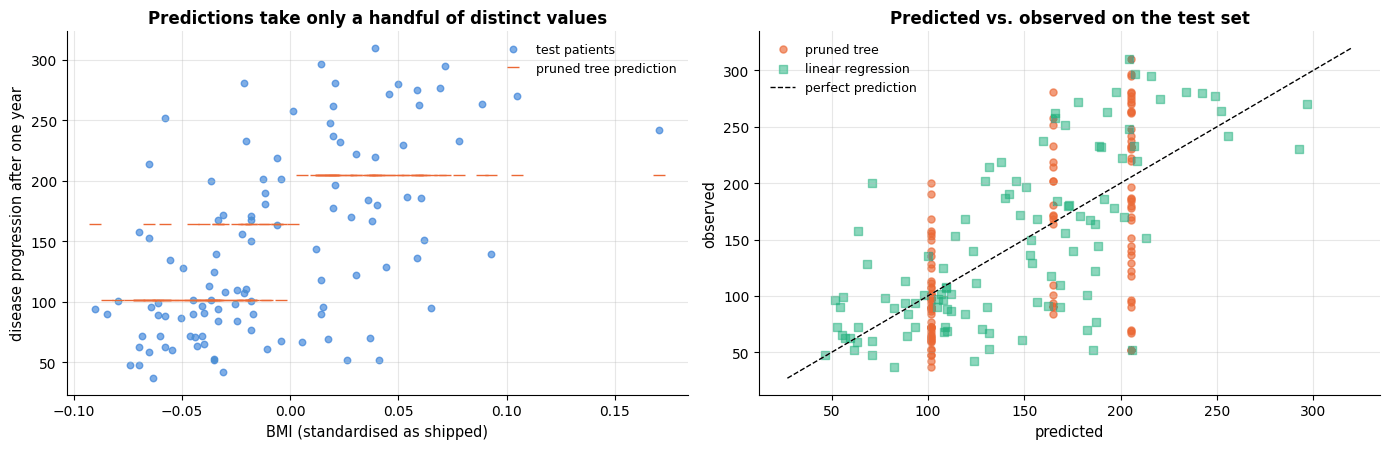

the pruned tree produces 3 distinct predicted values for 111 test patients


In [31]:
bmi_idx = list(diabetes.feature_names).index("bmi")     # the column position of the BMI feature
order = np.argsort(Xd_te[:, bmi_idx])                     # test rows sorted by BMI
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
axes[0].scatter(Xd_te[:, bmi_idx], yd_te, s=22, alpha=0.6, color=PALETTE[0], label="test patients")
# lw=0 draws no connecting line and marker="_" a short horizontal dash at every prediction
axes[0].plot(Xd_te[order, bmi_idx], tree_reg.predict(Xd_te)[order], lw=0, marker="_", ms=9,
             color=PALETTE[1], label="pruned tree prediction")
axes[0].set_xlabel("BMI (standardised as shipped)")
axes[0].set_ylabel("disease progression after one year")
axes[0].set_title("Predictions take only a handful of distinct values")
axes[0].legend(fontsize=9)
axes[1].scatter(tree_reg.predict(Xd_te), yd_te, s=26, alpha=0.65, color=PALETTE[1], label="pruned tree")
axes[1].scatter(LinearRegression().fit(Xd_tr, yd_tr).predict(Xd_te), yd_te, s=26, alpha=0.5,
                color=PALETTE[2], marker="s", label="linear regression")      # marker="s": squares
lims = [yd_te.min() - 10, yd_te.max() + 10]
axes[1].plot(lims, lims, "k--", lw=1, label="perfect prediction")     # "k--": a black dashed line along y = x
axes[1].set_xlabel("predicted")
axes[1].set_ylabel("observed")
axes[1].set_title("Predicted vs. observed on the test set")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()
# np.unique returns the distinct values, so its length is the number of different predictions
print(f"the pruned tree produces {len(np.unique(tree_reg.predict(Xd_te)))} distinct predicted values "
      f"for {len(yd_te)} test patients")

Two results deserve a sentence each. First, **pruning matters enormously**: the fully grown
tree has hundreds of leaves and is worse than predicting the mean, while the pruned tree —
with a handful of leaves — cuts the test RMSE by more than ten points. Cross-validation
pushes this tree almost to a stump, and it is right to.

Second, and more interesting, **the tree loses to the linear model**, by a wide margin. That
is not a bug in the pruning; it is the inductive bias speaking. The diabetes target is close
to an additive, roughly linear function of a few variables (notebook 6), and a
piecewise-constant model can only approximate a smooth slope with steps — visible as the
horizontal stripes in the right-hand panel, where the tree emits a handful of distinct values
for 111 patients. To carve enough boxes to imitate a plane in ten dimensions, a tree needs
far more than 331 training patients. Trees win on *typical* tabular data with thresholds,
interactions and irrelevant features (Grinsztajn et al., 2022); they lose on small, smooth,
nearly linear problems. The right conclusion for a practitioner is the one from notebook 5:
run both, and let cross-validation decide.

What the tree *does* give you, and the linear model does not, is an immediate, auditable
statement of which variable splits the patients first and at what value — a starting point
for a conversation with a clinician, even when it is not the model you would deploy.

## Summary

- A decision tree recursively partitions the feature space into **axis-aligned boxes** and
  predicts a constant in each: the majority class or the mean.
- Splits are chosen greedily to maximise the **impurity decrease**, with Gini or entropy;
  strict concavity is why the misclassification rate is not used for growing.
- A tree is **invariant to monotone transformations** of each feature, so it needs no
  scaling; it handles missing values natively and interactions automatically.
- Unpruned trees **overfit badly**. Control size with `max_depth` / `min_samples_leaf`, or —
  better — grow fully and use **cost-complexity pruning**, choosing $\alpha$ by CV and the
  one-standard-error rule.
- Regression trees are **step functions**: they cannot extrapolate beyond the training range
  and their predictions are coarse.
- The two structural weaknesses are **oblique boundaries** (expensive staircases) and
  **variance** (a different sample gives a different tree). Impurity-based importances are
  biased towards high-cardinality features; use permutation importance instead.
- Averaging many bootstrap trees removes most of the variance at no cost in bias — which is
  exactly what notebook 10 does.

| Question | Answer |
|---|---|
| Do I need to scale the features? | No — trees only use ranks |
| Missing values? | Handled natively since scikit-learn 1.3 |
| Categorical features? | One-hot (or `HistGradientBoosting`'s native support) |
| How do I stop it overfitting? | `ccp_alpha` by CV, or `max_depth` + `min_samples_leaf` |
| Which parameter first? | One size knob; then stop |
| Can it extrapolate? | No — flat outside the training range |
| Are the probabilities usable? | Coarse; calibrate (notebook 7) or use an ensemble |
| Which importance measure? | Permutation importance on held-out data, not `feature_importances_` |
| It is not accurate enough | Use a random forest or gradient boosting (notebook 10) |

**Next steps:** notebook 10 turns the variance measured in section 8 into an advantage with
bagging, random forests and boosting; notebook 11 offers a different non-linear model
(kernel SVMs) with the opposite trade-off — smooth boundaries, no interpretability;
notebook 12 automates the hyper-parameter search sketched in section 10; notebook 17 returns
to feature importance, partial dependence and SHAP for tree models.

## Exercises

### Exercise 1 — Entropy splits (easy)
Change `gini_impurity` in section 2.3 into an entropy function and re-run the single-split
search on the toy data. Does the chosen root split change? Then compare
`criterion="gini"` and `criterion="log_loss"` by 5-fold CV on the wine data.

<details><summary>Solution sketch</summary>

```py
def entropy_impurity(counts):
    p = counts[counts > 0] / counts.sum()
    return float(-np.sum(p * np.log2(p)))
```
The root split is normally identical and the CV accuracies differ by less than one standard
error. Gini and entropy disagree on roughly 2 % of splits in practice (Raileanu & Stoffel,
2004); the choice is not worth tuning.
</details>

### Exercise 2 — Prune by hand (easy)
Take the unpruned tree on `X_noisy` and, using `cost_complexity_pruning_path`, build the
table of (α, number of leaves, training impurity, test accuracy). Verify that the leaf counts
are strictly decreasing and that the sequence of subtrees is nested (every split in a smaller
tree also appears in a larger one).

<details><summary>Solution sketch</summary>

Loop over `path.ccp_alphas`, fit with `ccp_alpha=a`, record `get_n_leaves()` and
`score(X_test, y_test)`. Nesting can be checked by comparing the sets of
`(feature, threshold)` pairs of consecutive trees: each must be a subset of the previous one.
</details>

### Exercise 3 — XOR and greedy blindness (medium)
Generate the XOR problem: $x_1, x_2 \sim U(-1,1)$ and $y = \mathbb{1}[x_1 x_2 > 0]$. Fit
trees of depth 1, 2 and 3 and report the training accuracy of each. Explain what a depth-1
tree sees, and why the impurity decrease of *every* first split is approximately zero.

<details><summary>Solution sketch</summary>

Depth 1 gives ~50 %: each single-feature split leaves both children at 50/50, so the gain is
≈ 0 and CART picks an arbitrary split. Depth 2 reaches ~100 % because the second level can
condition on the first. This is greedy blindness: the best *pair* of splits is invisible to
a one-step-ahead search — and the reason trees still work here is that they keep splitting
even when the immediate gain is tiny.
</details>

### Exercise 4 — The rotation experiment, extended (medium)
Repeat section 9.1 but add 8 pure-noise features to the data before fitting. How much worse
does the tree get at 45° now, and why? Compare with a tree fitted to the *rotated features
plus their first two principal components* (notebook 14).

<details><summary>Solution sketch</summary>

Noise features give the greedy search more opportunities to fit noise, so the staircase
degrades further; logistic regression with a penalty is much less affected. Adding the PCA
components restores the tree's accuracy almost completely, because one principal component
recovers the informative direction and the tree can then split on it — the standard trick
when you suspect oblique structure.
</details>

### Exercise 5 — Regression tree on a real target (medium)
Fit `DecisionTreeRegressor` to the California housing data via
`course_utils.load_california_housing()` (note whether you get the real data or the offline
stand-in). Tune `max_depth` by CV, plot predicted vs. observed, and compare the test RMSE
with `LinearRegression`. Which districts does the tree get badly wrong?

<details><summary>Solution sketch</summary>

A depth around 8–12 is usually best. The tree beats the linear model on RMSE because the
target depends non-linearly on income and location. The largest errors are at the capped
top of the target range — the tree, like every piecewise-constant model, predicts the mean
of a box and cannot represent the cap.
</details>

### Exercise 6 — Your own bagging (hard)
Implement bagging from scratch around `MyDecisionTree`: draw $B$ bootstrap samples, fit a
tree on each, average the class probabilities. Plot test accuracy against $B$ for
$B = 1, \dots, 50$ on the `X_var` data, and add the **out-of-bag** estimate: for each
training point, average only the trees that did not see it. How close is the OOB estimate to
the test accuracy?

<details><summary>Solution sketch</summary>

Keep a boolean matrix `in_bag[b, i]`. The OOB prediction for point $i$ averages
`proba[b, i]` over `~in_bag[:, i]`; about $1 - 1/e \approx 63.2$ % of the points appear in
each bootstrap sample, so every point has roughly $0.368B$ trees to vote on it. The OOB
accuracy tracks the test accuracy within a fraction of a point once $B \gtrsim 25$ — this is
the free validation set that notebook 10 exploits.
</details>

## References and further reading

### Textbooks

- Breiman, L., Friedman, J. H., Olshen, R. A., & Stone, C. J. (1984). *Classification and Regression Trees*. Wadsworth. — The book this notebook follows: binary splits, Gini, regression trees, cost-complexity pruning and the one-standard-error rule.
- James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer. (free at https://www.statlearning.com) — Chapter 8 covers trees, pruning and ensembles with excellent figures.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer. (free) — §9.2 is the definitive short treatment, including why the misclassification rate is not used for growing.
- Quinlan, J. R. (1993). *C4.5: Programs for Machine Learning*. Morgan Kaufmann. — The other tradition: information gain ratio, multi-way splits, rule extraction and pessimistic pruning.
- Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction*. MIT Press. (free) — §18.1 places CART in a probabilistic framework and connects it to adaptive basis functions.
- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly. — Chapter 6 is a practical tour of scikit-learn's tree API.

### Papers

- Quinlan, J. R. (1986). Induction of decision trees. *Machine Learning*, 1(1), 81–106. — ID3 and information gain.
- Morgan, J. N., & Sonquist, J. A. (1963). Problems in the analysis of survey data, and a proposal. *Journal of the American Statistical Association*, 58(302), 415–434. — AID, the ancestor of recursive partitioning.
- Hyafil, L., & Rivest, R. L. (1976). Constructing optimal binary decision trees is NP-complete. *Information Processing Letters*, 5(1), 15–17. — Why the greedy algorithm exists.
- Strobl, C., Boulesteix, A.-L., Zeileis, A., & Hothorn, T. (2007). Bias in random forest variable importance measures: illustrations, sources and a solution. *BMC Bioinformatics*, 8, 25. — The cardinality bias demonstrated in §7.3.
- Raileanu, L. E., & Stoffel, K. (2004). Theoretical comparison between the Gini index and information gain criteria. *Annals of Mathematics and Artificial Intelligence*, 41(1), 77–93. — How rarely the two criteria disagree.
- Breiman, L. (1996). Bagging predictors. *Machine Learning*, 24(2), 123–140. — Where the variance measured in §8 goes; the starting point of notebook 10.
- Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5–32. — `max_features` in its proper home.
- Rudin, C. (2019). Stop explaining black box machine learning models for high stakes decisions and use interpretable models instead. *Nature Machine Intelligence*, 1, 206–215. — The argument for small trees and rule lists in consequential settings.
- Grinsztajn, L., Oyallon, E., & Varoquaux, G. (2022). Why do tree-based models still outperform deep learning on typical tabular data? *NeurIPS 2022 Datasets and Benchmarks*. — Argues that axis-aligned, non-smooth, scale-invariant inductive bias is exactly what tabular data needs.
- Shotton, J., Fitzgibbon, A., Cook, M., Sharp, T., Finocchio, M., Moore, R., Kipman, A., & Blake, A. (2011). Real-time human pose recognition in parts from single depth images. *Proceedings of CVPR 2011*, 1297–1304. — Decision forests that label every pixel of a Kinect depth image in real time (§1.2).
- Efron, B., Hastie, T., Johnstone, I., & Tibshirani, R. (2004). Least angle regression. *The Annals of Statistics*, 32(2), 407–499. — Source of the diabetes data used in §11.2.

### Documentation and online resources

- scikit-learn user guide, *Decision Trees* — https://scikit-learn.org/stable/modules/tree.html — includes the complexity analysis and the practical-tips list.
- scikit-learn, *Post pruning decision trees with cost complexity pruning* — https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html
- scikit-learn user guide, *Permutation feature importance* — https://scikit-learn.org/stable/modules/permutation_importance.html — and the worked example on the impurity-importance bias.
- scikit-learn, *Support for missing values in decision trees* — https://scikit-learn.org/stable/modules/tree.html#missing-values-support